In [ ]:
# Cell A - imports, config & helpers
import os, gc, math, json, pickle, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ML / DL libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

!pip install xgboost
!pip install lightgbm

import xgboost as xgb
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Conv1D, MaxPooling1D, Flatten, TimeDistributed, Dropout, Input, ConvLSTM2D
from tensorflow.keras.layers import ConvLSTM2D, Bidirectional, Reshape
from tensorflow.keras.layers import RepeatVector
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# File names / paths - adjust if needed
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024.csv"   # <-- put your CSV filename here
OUTPUT_DIR = "model_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Working dir files:", len(os.listdir(".")), "Output dir:", OUTPUT_DIR)

# metrics helper
def metrics_dict(y_true, y_pred):
    mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
    if mask.sum() == 0:
        return {"MSE":np.nan,"RMSE":np.nan,"MAE":np.nan,"R2":np.nan}
    yt = np.array(y_true)[mask]
    yp = np.array(y_pred)[mask]
    mse = mean_squared_error(yt, yp)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    return {"MSE":float(mse),"RMSE":float(rmse),"MAE":float(mae),"R2":float(r2)}

# plotting helpers
def save_scatter_and_timeseries(df, model_name, ts_col='timestamp', actual_col='actual', pred_col='pred', out_dir=OUTPUT_DIR):
    df2 = df.dropna(subset=[actual_col, pred_col]).copy()
    # scatter (sample up to 1000)
    samp = df2.sample(min(len(df2), 1000), random_state=42) if len(df2) else df2
    plt.figure(figsize=(6,5))
    plt.scatter(samp[actual_col], samp[pred_col], s=12, alpha=0.6)
    mx = max(samp[actual_col].max() if len(samp) else 1, samp[pred_col].max() if len(samp) else 1)
    plt.plot([0,mx],[0,mx], '--', color='red')
    plt.xlabel("Actual PM2.5")
    plt.ylabel("Predicted PM2.5")
    plt.title(f"Scatter: {model_name}")
    plt.tight_layout()
    scfile = os.path.join(out_dir, f"{model_name}_scatter.png")
    plt.savefig(scfile, dpi=150); plt.close()
    # timeseries: first 500 paired points
    ts = df2.sort_values(ts_col).head(500)
    plt.figure(figsize=(9,3))
    plt.plot(ts[ts_col], ts[actual_col], label='Actual', linewidth=1)
    plt.plot(ts[ts_col], ts[pred_col], label='Predicted', linewidth=1)
    plt.legend(fontsize=8)
    plt.title(f"Timeseries: {model_name} (first {len(ts)})")
    plt.xlabel("Timestamp")
    plt.ylabel("PM2.5")
    plt.tight_layout()
    tsfile = os.path.join(out_dir, f"{model_name}_timeseries.png")
    plt.savefig(tsfile, dpi=150); plt.close()
    return scfile, tsfile

def clear_ram():
    try:
        K.clear_session()
    except:
        pass
    gc.collect()
    print("Cleared RAM / session.")

print("Helpers loaded.")


Working dir files: 6 Output dir: model_plots
Helpers loaded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Robust CSV loader + cleaner (single cell) — paste & run in Colab
import os, csv, io
import pandas as pd
from collections import Counter

CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # change if your file has a different name
OUT_FIXED = "mandi_Gobindgarh_2017_2024_cleaned_fixed.csv"

assert os.path.exists(CLEANED_CSV), f"File not found: {CLEANED_CSV}"

def sniff_delimiter(path, n_chars=10000):
    # read a chunk and try csv.Sniffer
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        sample = f.read(n_chars)
    try:
        dialect = csv.Sniffer().sniff(sample)
        delim = dialect.delimiter
        return delim
    except Exception:
        # fallback guesses
        for d in [',',';', '\t','|']:
            if sample.count(d) > 0:
                return d
    return ','

print("Detecting delimiter (sniffer)...")
delim = sniff_delimiter(CLEANED_CSV)
print("Guessed delimiter:", repr(delim))

# Attempt 1: pandas read with python engine and on_bad_lines='warn' (will skip problematic rows but show warnings)
print("\nAttempting pd.read_csv(engine='python', on_bad_lines='warn') ...")
try:
    df_trial = pd.read_csv(CLEANED_CSV, sep=delim, engine='python', parse_dates=False, on_bad_lines='warn', low_memory=False)
    print("Read successful. Shape:", df_trial.shape)
    print("Columns:", list(df_trial.columns)[:20])
    df_trial.head(3)
    # save it as fixed copy
    df_trial.to_csv(OUT_FIXED, index=False)
    print(f"Saved cleaned-ish file (skipped bad lines) -> {OUT_FIXED}")
    raise SystemExit("Loaded via pandas; stop here (you can continue to next notebook cells).")
except SystemExit:
    pass
except Exception as e:
    print("pd.read_csv attempt 1 failed or had to skip lines. Error:", type(e).__name__, str(e))

# If we reached here, there were still problems. Let's scan file line-by-line to find inconsistent column counts.
print("\nScanning file for inconsistent field counts using the guessed delimiter...")
expected_fields = None
bad_lines = []
line_counts = Counter()
with open(CLEANED_CSV, 'r', encoding='utf-8', errors='ignore') as fh:
    for i, raw in enumerate(fh, start=1):
        # quick heuristic: split by delim (not robust for quoted fields, but finds many problems)
        cnt = raw.count(delim) + 1
        line_counts[cnt] += 1
        if expected_fields is None and i <= 30:
            # set expected to mode of first 30 lines
            pass
# pick modal count across entire file as expected (best-effort)
modal_count, modal_freq = line_counts.most_common(1)[0]
expected_fields = modal_count
print("Modal number of fields (best guess):", expected_fields, "occurs", modal_freq, "times. Dist of counts (top 10):", line_counts.most_common(10))

# Now iterate again but parse with csv.reader to get true split respecting quotes; collect lines that don't match expected_fields
print("\nParsing with csv.reader (handles quotes) to detect problematic lines...")
bad_lines = []
with open(CLEANED_CSV, 'r', encoding='utf-8', errors='ignore', newline='') as fh:
    reader = csv.reader(fh, delimiter=delim)
    for i, row in enumerate(reader, start=1):
        if len(row) != expected_fields:
            bad_lines.append((i, len(row)))
            if len(bad_lines) <= 20:
                print("  Problem at line", i, "fields:", len(row))
# report
print(f"\nFound {len(bad_lines)} lines with field-count != {expected_fields} (showing up to 20).")

if len(bad_lines) == 0:
    print("No inconsistent lines found with csv.reader. Trying to read with pandas again (this time quoting=csv.QUOTE_NONE)...")

# Try fallback: read with quoting disabled (QUOTE_NONE) — useful when stray quotes break parser
if len(bad_lines) > 0:
    print("\nAttempting fallback read with quoting=csv.QUOTE_NONE (often fixes stray-quote issues)...")
    try:
        df_fallback = pd.read_csv(CLEANED_CSV, sep=delim, engine='python',
                                  quoting=csv.QUOTE_NONE, error_bad_lines=False, warn_bad_lines=True,
                                  parse_dates=False, low_memory=False)
        print("Fallback read succeeded. Shape:", df_fallback.shape)
        df_fallback.to_csv(OUT_FIXED, index=False)
        print(f"Saved fallback-cleaned file -> {OUT_FIXED}")
    except Exception as e:
        print("Fallback read failed:", type(e).__name__, str(e))
        print("\nAs final fallback we will create a cleaned file by skipping lines whose field count differs from modal_count.")
        # create new cleaned file skipping bad lines
        in_path = CLEANED_CSV
        out_path = OUT_FIXED
        kept = 0
        skipped = 0
        with open(in_path, 'r', encoding='utf-8', errors='ignore') as inf, open(out_path, 'w', encoding='utf-8', newline='') as outf:
            writer = None
            for i, line in enumerate(inf, start=1):
                # split using csv.reader on that single line to handle quotes properly
                try:
                    row = next(csv.reader([line], delimiter=delim))
                except Exception:
                    row = line.split(delim)
                if len(row) == expected_fields:
                    if writer is None:
                        # initialize writer with header field count: create generic header if missing
                        writer = csv.writer(outf, delimiter=delim)
                    writer.writerow(row)
                    kept += 1
                else:
                    skipped += 1
        print(f"Fallback cleaning complete. Kept {kept} lines, skipped {skipped}. Output -> {out_path}")
        # try reading cleaned file
        try:
            df_fixed = pd.read_csv(out_path, sep=delim, engine='python', low_memory=False)
            print("Now loaded cleaned file shape:", df_fixed.shape)
        except Exception as e2:
            print("Still cannot read cleaned file. Error:", type(e2).__name__, str(e2))

# Final step: if OUT_FIXED exists, show preview
if os.path.exists(OUT_FIXED):
    print("\nPreview of cleaned file (first 5 rows):")
    try:
        dfc = pd.read_csv(OUT_FIXED, nrows=5)
        display(dfc)
    except Exception as e:
        print("Couldn't preview cleaned CSV using pandas:", e)

print("\nDone. If you still have issues, paste here the first 30 lines of your CSV (or upload the CSV) and I'll produce a cleaned version for you.")


Detecting delimiter (sniffer)...
Guessed delimiter: ','

Attempting pd.read_csv(engine='python', on_bad_lines='warn') ...
pd.read_csv attempt 1 failed or had to skip lines. Error: ValueError The 'low_memory' option is not supported with the 'python' engine

Scanning file for inconsistent field counts using the guessed delimiter...
Modal number of fields (best guess): 57 occurs 105889 times. Dist of counts (top 10): [(57, 105889)]

Parsing with csv.reader (handles quotes) to detect problematic lines...

Found 0 lines with field-count != 57 (showing up to 20).
No inconsistent lines found with csv.reader. Trying to read with pandas again (this time quoting=csv.QUOTE_NONE)...

Done. If you still have issues, paste here the first 30 lines of your CSV (or upload the CSV) and I'll produce a cleaned version for you.


In [ ]:
# ===========================
# Cell 1 – Setup & Libraries
# ===========================
import os, gc, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paths
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"  # your cleaned file
assert os.path.exists(CLEANED_CSV), "⚠️ CSV file not found in working dir."

print("✅ Environment ready. File found:", CLEANED_CSV)


✅ Environment ready. File found: /content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv


In [ ]:
# ===================================
# Cell 2 – Safe CSV loader
# ===================================
print("Loading cleaned CSV:", CLEANED_CSV)

df = pd.read_csv(CLEANED_CSV, parse_dates=['timestamp'], low_memory=False)
print(f"Loaded shape: {df.shape}")
print(f"Time span: {df['timestamp'].min()} → {df['timestamp'].max()}")

# Sort chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

# Drop any duplicate timestamps or NA rows (rare)
df = df.drop_duplicates(subset=['timestamp']).dropna(subset=['pm2_5'])

print("✅ Data cleaned. Remaining rows:", len(df))
print("Columns:", list(df.columns))


Loading cleaned CSV: /content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv
Loaded shape: (105888, 57)
Time span: 2017-01-06 00:00:00 → 2024-12-12 23:45:00
✅ Data cleaned. Remaining rows: 105888
Columns: ['timestamp', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'eth_benzene', 'apparent_temperature', 'rh', 'wind_speed', 'wind_dir', 'rain', 'tot_rain', 'solar_radiapparent_temperatureion', 'source_file', 'source_year', 'year', 'month', 'day', 'hour', 'minute', 'is_burning_month', 'dayofyear', 'doy_sin', 'doy_cos', 'hour_sin', 'hour_cos', 'wind_x', 'wind_y', 'pm2_5_lag1', 'pm2_5_lag4', 'pm2_5_lag12', 'pm2_5_lag24', 'pm2_5_lag96', 'pm2_5_rollmean_4', 'pm2_5_rollstd_4', 'pm2_5_rollmean_24', 'pm2_5_rollstd_24', 'pm2_5_rollmean_96', 'pm2_5_rollstd_96', 'pm10_lag1', 'pm10_lag4', 'pm10_lag12', 'pm10_lag24', 'pm10_lag96', 'pm10_rollmean_4', 'pm10_rollstd_4', 'pm10_rollmean_24', 'pm10_rollstd_24', 'pm10_rollmean_96', 'pm10_rollstd_96']


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Force TensorFlow to use GPU if available
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"✅ GPU enabled: {len(gpus)} physical, {len(logical_gpus)} logical.")
    except RuntimeError as e:
        print("⚠️ GPU setup error:", e)
else:
    print("❌ No GPU found. Go to Runtime → Change runtime type → GPU.")


✅ GPU enabled: 1 physical, 1 logical.


✅ Normalization done. Feature mean/std (≈0,1): -0.0 1.0
Target mean/std: 0.0 1.0
Sequences → Train:(95256, 48, 56) Val:(10584, 48, 56)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        94,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,241 (571.25 KB)

 Trainable params: 146,241 (571.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50

Epoch 1: val_loss improved from inf to 0.08428, saving model to models/LSTM_best.keras
745/745 - 19s - 25ms/step - loss: 0.2385 - mae: 0.2814 - val_loss: 0.0843 - val_mae: 0.1880 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_loss improved from 0.08428 to 0.05879, saving model to models/LSTM_best.keras
745/745 - 7s - 9ms/step - loss: 0.1133 - mae: 0.1855 - val_loss: 0.0588 - val_mae: 0.1257 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_loss did not improve from 0.05879
745/745 - 7s - 10ms/step - loss: 0.0900 - mae: 0.1621 - val_loss: 0.0662 - val_mae: 0.1580 - learning_rate: 1.0000e-03
Epoch 4/50

Epoch 4: val_loss did not improve from 0.05879
745/745 - 6s - 9ms/step - loss: 0.0837 - mae: 0.1517 - val_loss: 0.0624 - val_mae: 0.1437 - learning_rate: 1.0000e-03
Epoch 5/50

Epoch 5: val_loss did not improve from 0.05879
745/745 - 7s - 10ms/step - loss: 0.0801 - mae: 0.1482 - val_loss: 0.0639 - val_mae: 0.1396 - learning_rate: 1.0000e-03
Epoch 6/50

Epoch 6: val_lo

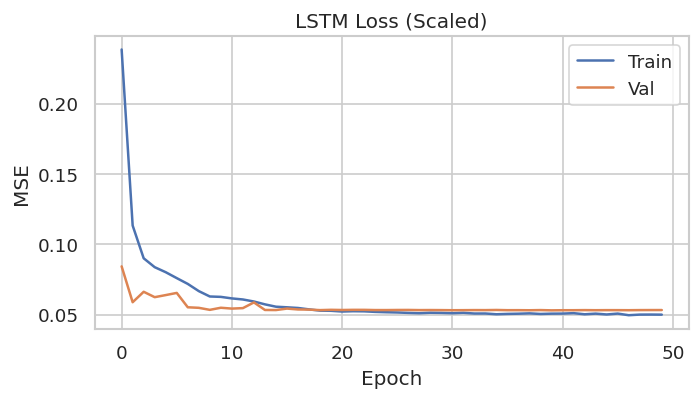

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
📊 Metrics (original units): {'MSE': 221.1648712158203, 'RMSE': 14.871612932557797, 'MAE': 7.239767074584961, 'R2': 0.9371749758720398}
Saved predictions → predictions_15min/LSTM_best_predictions_scaled_inverse.csv


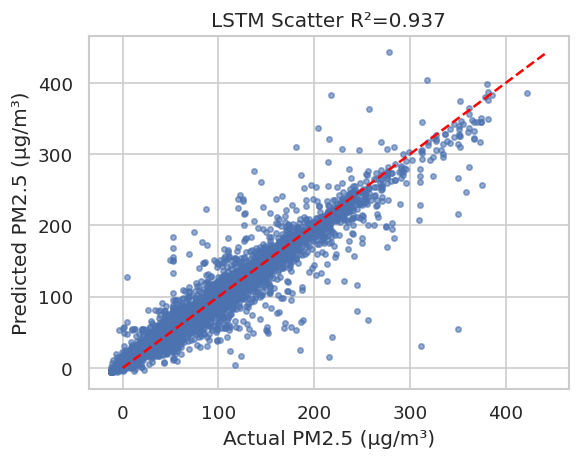

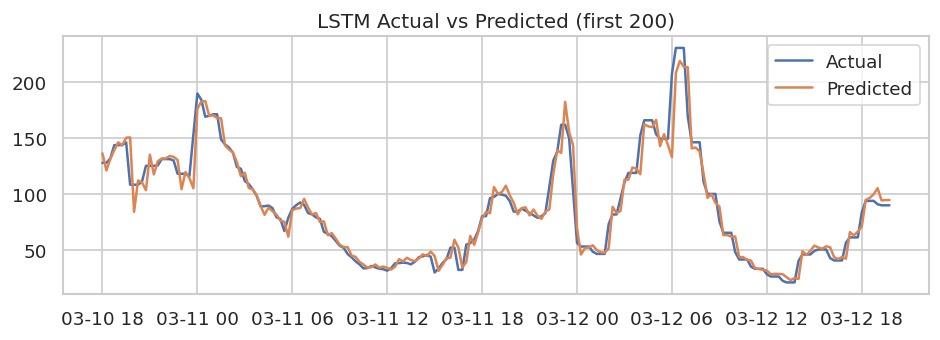

🧹 Memory cleared. LSTM normalized training complete.


In [ ]:
# ================================================================
# ✅ Cell 4 — LSTM (with normalization, inverse scaling & callbacks)
# ================================================================
import os, gc, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ---------------------------
# CONFIG
# ---------------------------
BATCH_SIZE = 128
EPOCHS = 50
INIT_LR = 1e-3
SEQ_LEN = 48
MODEL_DIR = "models"
PRED_DIR = "predictions_15min"
PLOT_DIR = "plots_15min"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ---------------------------
# LOAD & NORMALIZE DATA
# ---------------------------
assert 'df' in globals(), "Run preprocessing to create the DataFrame 'df' first."
df_scaled = df.copy()

# Select numeric columns (exclude timestamp)
num_cols = [c for c in df_scaled.columns if c != 'timestamp']
feature_cols = [c for c in num_cols if c != 'pm2_5']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

df_scaled[feature_cols] = scaler_X.fit_transform(df_scaled[feature_cols])
df_scaled['pm2_5'] = scaler_y.fit_transform(df_scaled[['pm2_5']])

print("✅ Normalization done. Feature mean/std (≈0,1):",
      round(df_scaled[feature_cols].mean().mean(), 2),
      round(df_scaled[feature_cols].std().mean(), 2))
print("Target mean/std:",
      round(df_scaled['pm2_5'].mean(), 2),
      round(df_scaled['pm2_5'].std(), 2))

# ---------------------------
# CREATE SEQUENCES
# ---------------------------
def create_sequences(data, seq_len=SEQ_LEN, target_col='pm2_5'):
    X, y = [], []
    values = data.drop(columns=['timestamp']).values
    target_idx = data.columns.get_loc(target_col)
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len, :])
        y.append(values[i+seq_len, target_idx])
    return np.array(X, dtype='float32'), np.array(y, dtype='float32')

X_all, y_all = create_sequences(df_scaled)
train_ratio = 0.9
split_idx = int(len(X_all) * train_ratio)
X_train, X_val = X_all[:split_idx], X_all[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]
print(f"Sequences → Train:{X_train.shape} Val:{X_val.shape}")

# ---------------------------
# DATASET CREATION
# ---------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ---------------------------
# MODEL
# ---------------------------
def build_lstm(input_shape):
    m = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.15),
        LSTM(64),
        Dropout(0.15),
        Dense(32, activation='relu'),
        Dense(1, dtype='float32')
    ])
    return m

input_shape = (SEQ_LEN, X_train.shape[2])
model = build_lstm(input_shape)
model.compile(optimizer=Adam(learning_rate=INIT_LR), loss='mse', metrics=['mae'])
model.summary()

# ---------------------------
# CALLBACKS
# ---------------------------
ckpt_path = os.path.join(MODEL_DIR, "LSTM_best.keras")
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4,
                      min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
]

# ---------------------------
# TRAIN
# ---------------------------
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                    callbacks=callbacks, verbose=2)

print("✅ Training done. Best model saved to:", ckpt_path)

# ---------------------------
# LOSS PLOT
# ---------------------------
plt.figure(figsize=(6,3.5))
plt.plot(history.history.get('loss', []), label='Train')
plt.plot(history.history.get('val_loss', []), label='Val')
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("LSTM Loss (Scaled)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/LSTM_loss_scaled.png", dpi=150)
plt.show()

# ---------------------------
# PREDICTION (inverse-transform)
# ---------------------------
best_model = tf.keras.models.load_model(ckpt_path)
y_pred_scaled = best_model.predict(X_val, batch_size=BATCH_SIZE).ravel()

# Inverse-transform predictions & true values
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_true = scaler_y.inverse_transform(y_val.reshape(-1,1)).ravel()

# Metrics in original units
mse = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print("📊 Metrics (original units):", {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2})

# ---------------------------
# SAVE PREDICTIONS & PLOTS
# ---------------------------
outdf = pd.DataFrame({
    "timestamp": df['timestamp'].iloc[-len(y_true):].values,
    "actual": y_true, "pred": y_pred
})
outdf.to_csv(f"{PRED_DIR}/LSTM_best_predictions_scaled_inverse.csv", index=False)
print("Saved predictions →", f"{PRED_DIR}/LSTM_best_predictions_scaled_inverse.csv")

# Scatter
plt.figure(figsize=(5,4))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
mx = max(max(y_true), max(y_pred))
plt.plot([0,mx],[0,mx],'--',color='red')
plt.xlabel("Actual PM2.5 (µg/m³)"); plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"LSTM Scatter R²={r2:.3f}")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/LSTM_scatter_inverse.png", dpi=150)
plt.show()

# Time series overlay (first 600 samples)
plt.figure(figsize=(8,3))
plt.plot(outdf['timestamp'].head(200), outdf['actual'].head(200), label='Actual')
plt.plot(outdf['timestamp'].head(200), outdf['pred'].head(200), label='Predicted')
plt.legend(); plt.title("LSTM Actual vs Predicted (first 200)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/LSTM_timeseries_inverse.png", dpi=150)
plt.show()

# ---------------------------
# CLEANUP
# ---------------------------
del model, best_model, history, X_all, y_all, X_train, X_val, y_train, y_val
gc.collect()
tf.keras.backend.clear_session()
print("🧹 Memory cleared. LSTM normalized training complete.")


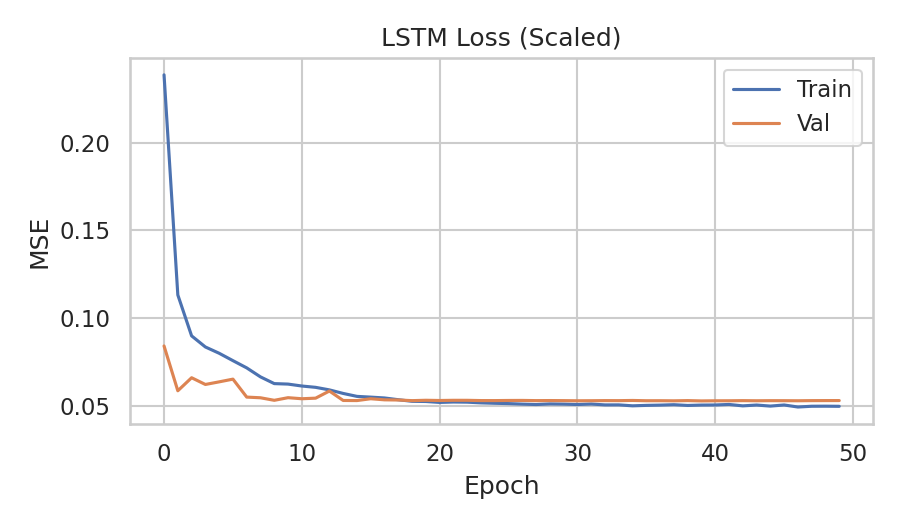

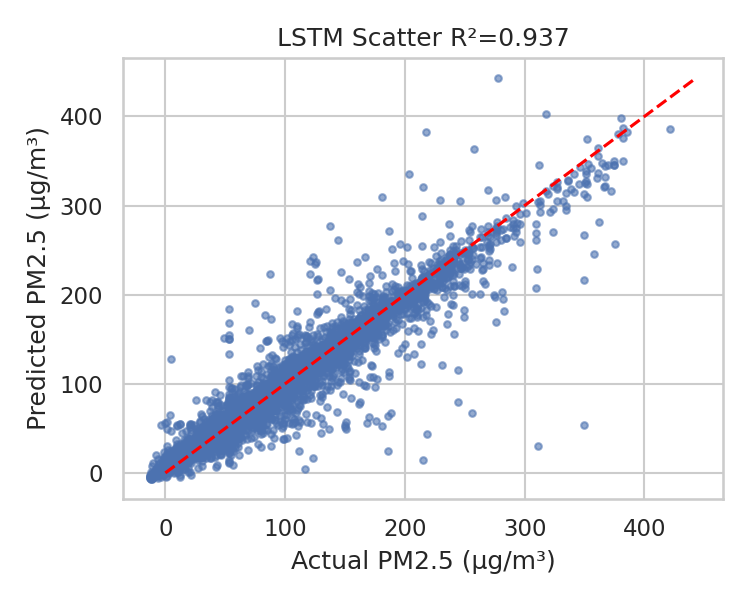

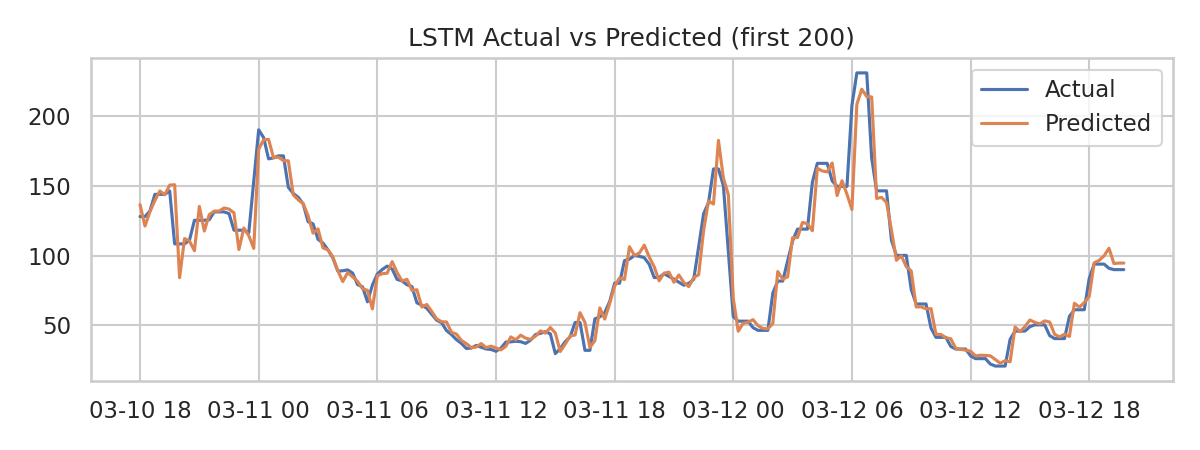

In [ ]:
## A — Show the saved loss + scatter + timeseries plots inline
from IPython.display import Image, display
display(Image("plots_15min/LSTM_loss_scaled.png"))
display(Image("plots_15min/LSTM_scatter_inverse.png"))
display(Image("plots_15min/LSTM_timeseries_inverse.png"))


In [ ]:
##B — Reload the best model and predict on any new array (X_new_scaled)

import tensorflow as tf, numpy as np, pandas as pd
best = tf.keras.models.load_model("models/LSTM_best.keras")
# Example: predict on X_val (if still present)
# preds_scaled = best.predict(X_val, batch_size=128).ravel()
# preds = scaler_y.inverse_transform(preds_scaled.reshape(-1,1)).ravel()
# print(preds[:10])


In [ ]:
##Reload the CSV of saved predictions

import pandas as pd
outdf = pd.read_csv("predictions_15min/LSTM_best_predictions_scaled_inverse.csv", parse_dates=['timestamp'])
outdf.head()


,timestamp,actual,pred
0,2024-03-10 18:00:00,127.93593,136.422150
1,2024-03-10 18:15:00,127.93593,121.121124
2,2024-03-10 18:30:00,131.90337,131.409030
3,2024-03-10 18:45:00,143.81815,139.408250
4,2024-03-10 19:00:00,143.81815,146.265960


In [ ]:
##Free GPU/RAM (run after each heavy cell)

import gc, tensorflow as tf
del best
gc.collect()
tf.keras.backend.clear_session()
print("RAM/TF cleared.")


RAM/TF cleared.


Sequences → Train: (95256, 48, 56) Val: (10584, 48, 56)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 48, 128)        │        71,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,785 (432.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50

Epoch 1: val_loss improved from inf to 0.13263, saving model to models/GRU_best.keras
373/373 - 7s - 20ms/step - loss: 0.2040 - mae: 0.2635 - val_loss: 0.1326 - val_mae: 0.2610 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_loss improved from 0.13263 to 0.07603, saving model to models/GRU_best.keras
373/373 - 4s - 10ms/step - loss: 0.1207 - mae: 0.2012 - val_loss: 0.0760 - val_mae: 0.1721 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_loss improved from 0.07603 to 0.06992, saving model to models/GRU_best.keras
373/373 - 4s - 12ms/step - loss: 0.0967 - mae: 0.1742 - val_loss: 0.0699 - val_mae: 0.1607 - learning_rate: 1.0000e-03
Epoch 4/50

Epoch 4: val_loss did not improve from 0.06992
373/373 - 5s - 12ms/step - loss: 0.0890 - mae: 0.1642 - val_loss: 0.0779 - val_mae: 0.1860 - learning_rate: 1.0000e-03
Epoch 5/50

Epoch 5: val_loss did not improve from 0.06992
373/373 - 4s - 10ms/step - loss: 0.0822 - mae: 0.1548 - val_loss: 0.0922 - val_mae: 0.2269 - learning_ra

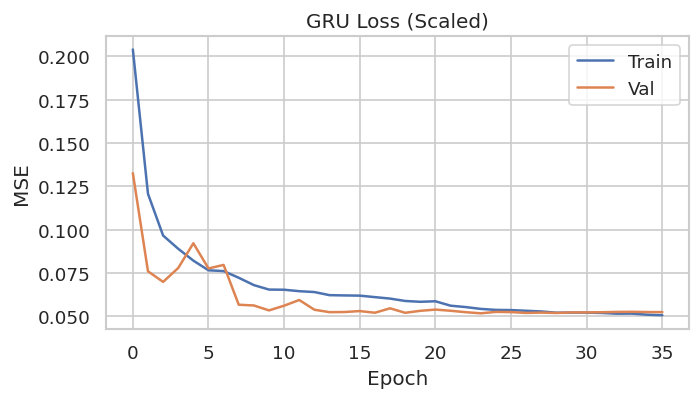

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
GRU metrics: {'MSE': 216.06008911132812, 'RMSE': 14.698982587625856, 'MAE': 7.048752784729004, 'R2': 0.9386250972747803}
Saved predictions -> predictions_15min/GRU_best_predictions_scaled_inverse.csv
Memory cleared. GRU done.


In [ ]:
# ======================
# Cell 5 — GRU (same flow as LSTM)
# ======================
import os, gc, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Config (adjust if you want)
BATCH_SIZE = 256
EPOCHS = 50
INIT_LR = 1e-3
SEQ_LEN = 48
MODEL_DIR = "models"
PRED_DIR = "predictions_15min"
PLOT_DIR = "plots_15min"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# We assume df_scaled and scaler_y exist (from Cell 4). If not, re-run normalization cell from Cell 4.
assert 'df' in globals(), "Run cell that loads df first."

# If you still have df_scaled and scaler_y in memory (from earlier run) reuse them:
try:
    df_scaled  # exists?
except NameError:
    # Recreate scaled data using scalers saved in globals from previous run (if present)
    # If not available, run the same StandardScaler steps as in Cell 4.
    from sklearn.preprocessing import StandardScaler
    df_scaled = df.copy()
    feature_cols = [c for c in df_scaled.columns if c not in ['timestamp','pm2_5']]
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    df_scaled[feature_cols] = scaler_X.fit_transform(df_scaled[feature_cols])
    df_scaled['pm2_5'] = scaler_y.fit_transform(df_scaled[['pm2_5']])

# Create sequences (same helper as LSTM)
def create_sequences(data, seq_len=SEQ_LEN, target_col='pm2_5'):
    X, y = [], []
    values = data.drop(columns=['timestamp']).values
    target_idx = data.columns.get_loc(target_col)
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len, :])
        y.append(values[i+seq_len, target_idx])
    return np.array(X, dtype='float32'), np.array(y, dtype='float32')

X_all, y_all = create_sequences(df_scaled, seq_len=SEQ_LEN)
train_ratio = 0.9
split_idx = int(len(X_all) * train_ratio)
X_train, X_val = X_all[:split_idx], X_all[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]
print("Sequences → Train:", X_train.shape, "Val:", X_val.shape)

# tf.data
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Build GRU model
def build_gru(input_shape):
    m = Sequential([
        GRU(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.15),
        GRU(64),
        Dropout(0.15),
        Dense(32, activation='relu'),
        Dense(1, dtype='float32')
    ])
    return m

input_shape = (SEQ_LEN, X_train.shape[2])
model = build_gru(input_shape)
model.compile(optimizer=Adam(learning_rate=INIT_LR), loss='mse', metrics=['mae'])
model.summary()

# callbacks
ckpt_path = os.path.join(MODEL_DIR, "GRU_best.keras")
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
]

# train
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
print("Training done. Best model saved to:", ckpt_path)

# plot loss
plt.figure(figsize=(6,3.5))
plt.plot(history.history.get('loss', []), label='Train')
plt.plot(history.history.get('val_loss', []), label='Val')
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("GRU Loss (Scaled)"); plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/GRU_loss_scaled.png", dpi=150); plt.show()

# predict & inverse transform
best_model = tf.keras.models.load_model(ckpt_path)
y_pred_scaled = best_model.predict(X_val, batch_size=BATCH_SIZE).ravel()
# use the scaler_y from previous LSTM run (must exist). If not, re-fit or save it earlier.
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_true = scaler_y.inverse_transform(y_val.reshape(-1,1)).ravel()

mse = mean_squared_error(y_true, y_pred); rmse = math.sqrt(mse); mae = mean_absolute_error(y_true, y_pred); r2 = r2_score(y_true, y_pred)
print("GRU metrics:", {"MSE":mse,"RMSE":rmse,"MAE":mae,"R2":r2})

outdf = pd.DataFrame({"timestamp": df['timestamp'].iloc[-len(y_true):].values, "actual": y_true, "pred": y_pred})
outdf.to_csv(os.path.join(PRED_DIR,"GRU_best_predictions_scaled_inverse.csv"), index=False)
print("Saved predictions ->", os.path.join(PRED_DIR,"GRU_best_predictions_scaled_inverse.csv"))

# cleanup
del model, best_model, history, X_all, y_all, X_train, X_val, y_train, y_val
gc.collect()
tf.keras.backend.clear_session()
print("Memory cleared. GRU done.")


In [ ]:
# === Free RAM cell ===
import gc, tensorflow as tf
gc.collect()
tf.keras.backend.clear_session()
print("Cleared TF session and ran garbage collection.")


Cleared TF session and ran garbage collection.


Loaded: 10584 rows
RMSE=14.699, MAE=7.049, R²=0.939


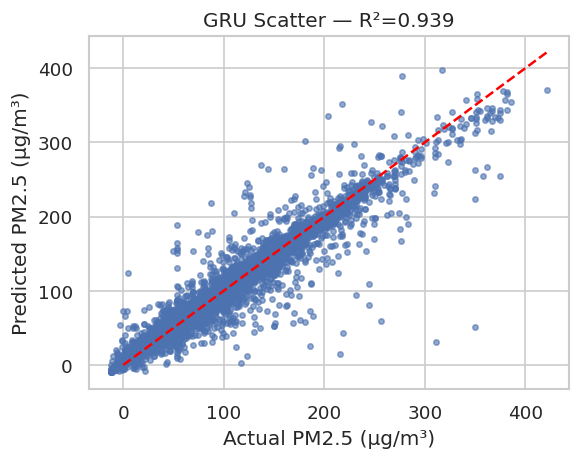

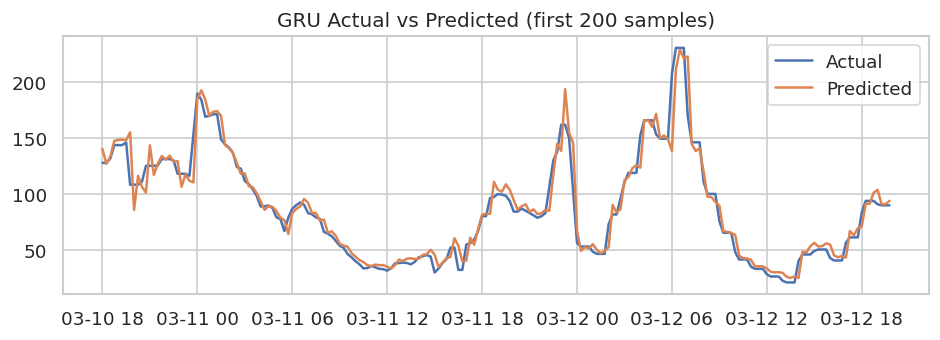

✅ Saved GRU_scatter_inverse.png and GRU_timeseries_inverse.png


In [ ]:
# === Create GRU scatter & time-series plots ===
import pandas as pd, matplotlib.pyplot as plt, numpy as np, os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PLOT_DIR = "plots_15min"
os.makedirs(PLOT_DIR, exist_ok=True)

# load GRU predictions
gru_pred_path = "predictions_15min/GRU_best_predictions_scaled_inverse.csv"
df_gru = pd.read_csv(gru_pred_path, parse_dates=['timestamp'])
print("Loaded:", len(df_gru), "rows")

# compute metrics (just to confirm)
mse = mean_squared_error(df_gru['actual'], df_gru['pred'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(df_gru['actual'], df_gru['pred'])
r2 = r2_score(df_gru['actual'], df_gru['pred'])
print(f"RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")

# scatter plot
plt.figure(figsize=(5,4))
plt.scatter(df_gru['actual'], df_gru['pred'], s=10, alpha=0.6)
mx = max(df_gru['actual'].max(), df_gru['pred'].max())
plt.plot([0,mx],[0,mx],'--',color='red')
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"GRU Scatter — R²={r2:.3f}")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/GRU_scatter_inverse.png", dpi=150)
plt.show()

# time-series overlay (first 600 samples)
plt.figure(figsize=(8,3))
plt.plot(df_gru['timestamp'].head(200), df_gru['actual'].head(200), label='Actual')
plt.plot(df_gru['timestamp'].head(200), df_gru['pred'].head(200), label='Predicted')
plt.legend()
plt.title("GRU Actual vs Predicted (first 200 samples)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/GRU_timeseries_inverse.png", dpi=150)
plt.show()

print("✅ Saved GRU_scatter_inverse.png and GRU_timeseries_inverse.png")


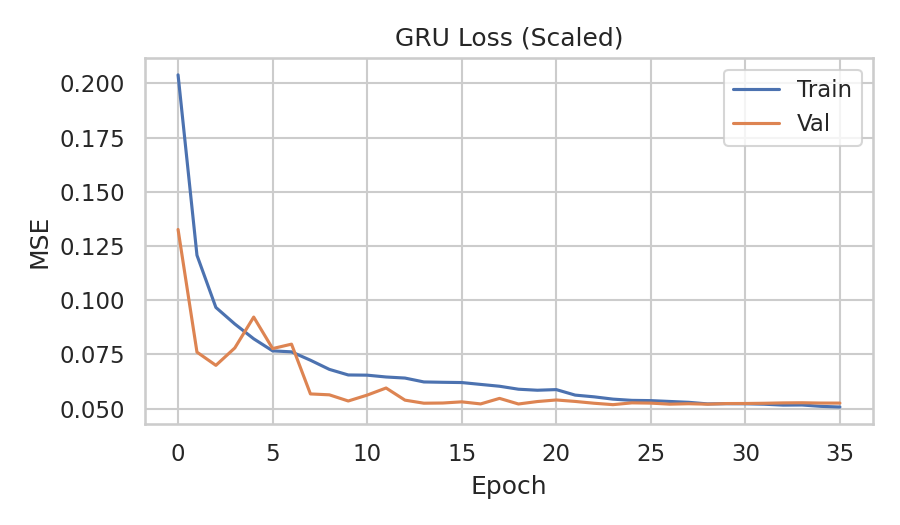

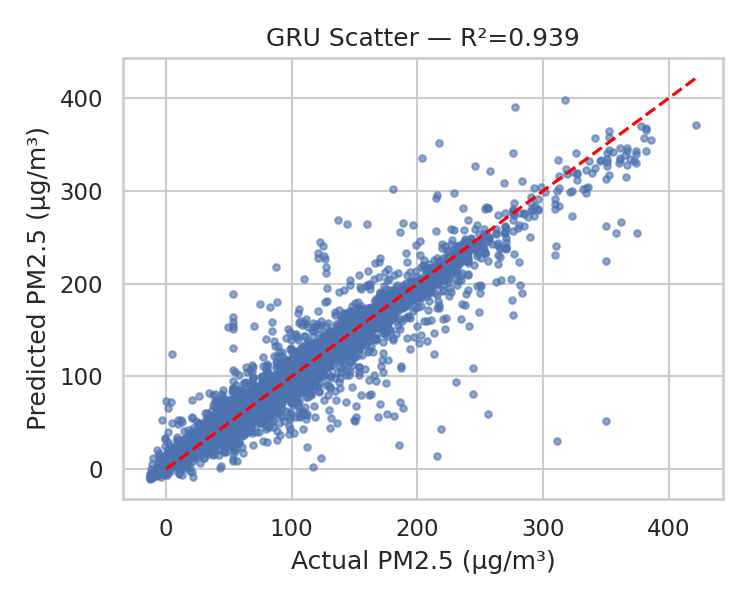

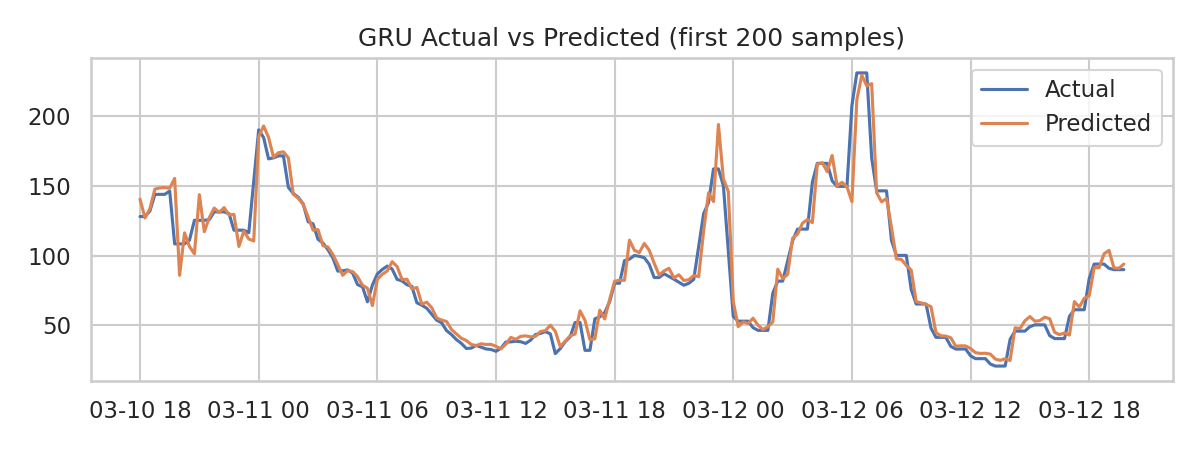

In [ ]:
# === Display GRU plots inline ===
from IPython.display import Image, display

display(Image("plots_15min/GRU_loss_scaled.png"))
display(Image("plots_15min/GRU_scatter_inverse.png"))
display(Image("plots_15min/GRU_timeseries_inverse.png"))


✅ Using existing normalized df_scaled from previous runs.
Scaled feature/target check: -0.0 1.0
Sequences → Train:(95256, 48, 56) Val:(10584, 48, 56)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 46, 64)         │        10,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,953 (179.50 KB)

 Trainable params: 45,953 (179.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50

Epoch 1: val_loss improved from inf to 0.27919, saving model to models/CNN_LSTM_best.keras
373/373 - 8s - 20ms/step - loss: 0.3189 - mae: 0.3455 - val_loss: 0.2792 - val_mae: 0.4154 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_loss improved from 0.27919 to 0.12859, saving model to models/CNN_LSTM_best.keras
373/373 - 3s - 9ms/step - loss: 0.1863 - mae: 0.2510 - val_loss: 0.1286 - val_mae: 0.2036 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_loss improved from 0.12859 to 0.11357, saving model to models/CNN_LSTM_best.keras
373/373 - 4s - 12ms/step - loss: 0.1528 - mae: 0.2243 - val_loss: 0.1136 - val_mae: 0.1897 - learning_rate: 1.0000e-03
Epoch 4/50

Epoch 4: val_loss improved from 0.11357 to 0.10898, saving model to models/CNN_LSTM_best.keras
373/373 - 5s - 14ms/step - loss: 0.1313 - mae: 0.2030 - val_loss: 0.1090 - val_mae: 0.2130 - learning_rate: 1.0000e-03
Epoch 5/50

Epoch 5: val_loss improved from 0.10898 to 0.09790, saving model to models/CNN_LSTM_best.

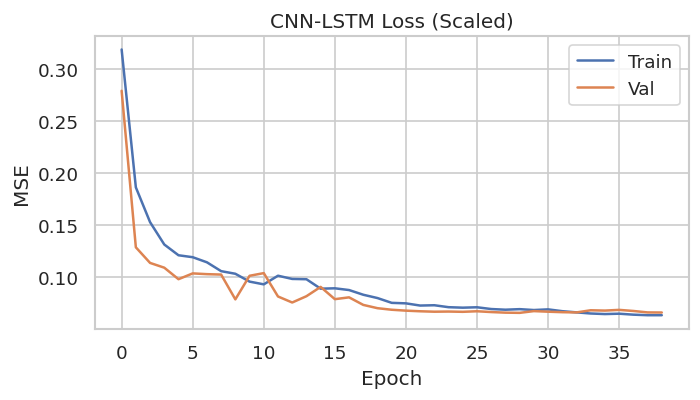

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
📊 CNN-LSTM metrics: {'MSE': 273.32196044921875, 'RMSE': 16.532451737392694, 'MAE': 8.948454856872559, 'R2': 0.922359049320221}
Saved predictions → predictions_15min/CNN_LSTM_best_predictions_scaled_inverse.csv


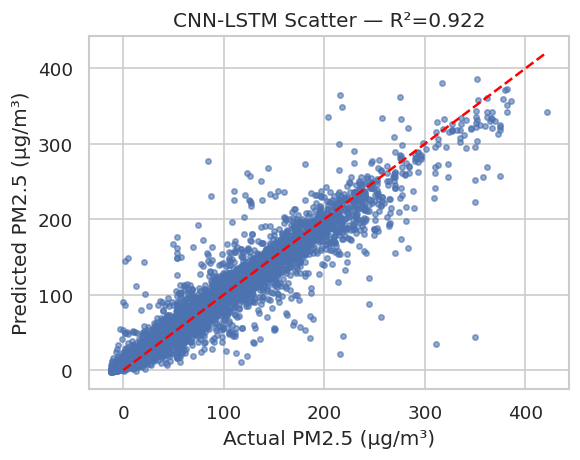

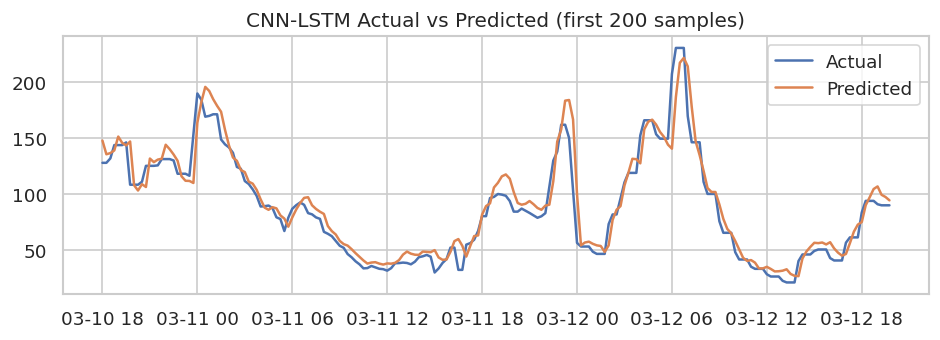

🧹 Memory cleared. CNN-LSTM training complete.


In [ ]:
# ================================================================
# ✅ Cell 6 — CNN-LSTM model (normalized, inverse-scaling, callbacks)
# ================================================================
import os, gc, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ---------------------------
# CONFIG
# ---------------------------
BATCH_SIZE = 256
EPOCHS = 50
INIT_LR = 1e-3
SEQ_LEN = 48
MODEL_DIR = "models"
PRED_DIR = "predictions_15min"
PLOT_DIR = "plots_15min"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ---------------------------
# LOAD & NORMALIZE (reuse scalers if exist)
# ---------------------------
assert 'df' in globals(), "⚠️ Please load DataFrame 'df' before running this cell."

try:
    df_scaled
    print("✅ Using existing normalized df_scaled from previous runs.")
except NameError:
    print("Scaling fresh copy ...")
    df_scaled = df.copy()
    feature_cols = [c for c in df.columns if c not in ['timestamp','pm2_5']]
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    df_scaled[feature_cols] = scaler_X.fit_transform(df_scaled[feature_cols])
    df_scaled['pm2_5'] = scaler_y.fit_transform(df_scaled[['pm2_5']])

print("Scaled feature/target check:", round(df_scaled[feature_cols].mean().mean(),2), round(df_scaled['pm2_5'].std(),2))

# ---------------------------
# CREATE SEQUENCES
# ---------------------------
def create_sequences(data, seq_len=SEQ_LEN, target_col='pm2_5'):
    X, y = [], []
    values = data.drop(columns=['timestamp']).values
    target_idx = data.columns.get_loc(target_col)
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len, :])
        y.append(values[i+seq_len, target_idx])
    return np.array(X, dtype='float32'), np.array(y, dtype='float32')

X_all, y_all = create_sequences(df_scaled, seq_len=SEQ_LEN)
split = int(len(X_all) * 0.9)
X_train, X_val = X_all[:split], X_all[split:]
y_train, y_val = y_all[:split], y_all[split:]
print(f"Sequences → Train:{X_train.shape} Val:{X_val.shape}")

# ---------------------------
# DATASETS
# ---------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ---------------------------
# MODEL DEFINITION
# ---------------------------
def build_cnn_lstm(input_shape):
    m = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.15),
        LSTM(64),
        Dropout(0.15),
        Dense(32, activation='relu'),
        Dense(1, dtype='float32')
    ])
    return m

input_shape = (SEQ_LEN, X_train.shape[2])
model = build_cnn_lstm(input_shape)
model.compile(optimizer=Adam(learning_rate=INIT_LR), loss='mse', metrics=['mae'])
model.summary()

# ---------------------------
# CALLBACKS
# ---------------------------
ckpt_path = os.path.join(MODEL_DIR, "CNN_LSTM_best.keras")
callbacks = [
    ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# ---------------------------
# TRAIN
# ---------------------------
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
print("✅ Training complete. Best model saved to:", ckpt_path)

# ---------------------------
# LOSS PLOT
# ---------------------------
plt.figure(figsize=(6,3.5))
plt.plot(history.history.get('loss', []), label='Train')
plt.plot(history.history.get('val_loss', []), label='Val')
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("CNN-LSTM Loss (Scaled)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/CNN_LSTM_loss_scaled.png", dpi=150)
plt.show()

# ---------------------------
# PREDICT + INVERSE-TRANSFORM
# ---------------------------
best_model = tf.keras.models.load_model(ckpt_path)
y_pred_scaled = best_model.predict(X_val, batch_size=BATCH_SIZE).ravel()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_true = scaler_y.inverse_transform(y_val.reshape(-1,1)).ravel()

# Metrics
mse = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
print("📊 CNN-LSTM metrics:", {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2})

# ---------------------------
# SAVE PREDICTIONS
# ---------------------------
out = pd.DataFrame({
    "timestamp": df['timestamp'].iloc[-len(y_true):].values,
    "actual": y_true,
    "pred": y_pred
})
pred_path = os.path.join(PRED_DIR, "CNN_LSTM_best_predictions_scaled_inverse.csv")
out.to_csv(pred_path, index=False)
print("Saved predictions →", pred_path)

# ---------------------------
# SCATTER + TIME SERIES PLOTS
# ---------------------------
plt.figure(figsize=(5,4))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
mx = max(y_true.max(), y_pred.max())
plt.plot([0,mx],[0,mx],'--',color='red')
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"CNN-LSTM Scatter — R²={r2:.3f}")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/CNN_LSTM_scatter_inverse.png", dpi=150)
plt.show()

plt.figure(figsize=(8,3))
plt.plot(out['timestamp'].head(200), out['actual'].head(200), label='Actual')
plt.plot(out['timestamp'].head(200), out['pred'].head(200), label='Predicted')
plt.legend()
plt.title("CNN-LSTM Actual vs Predicted (first 200 samples)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/CNN_LSTM_timeseries_inverse.png", dpi=150)
plt.show()

# ---------------------------
# CLEANUP
# ---------------------------
del model, best_model, history, X_all, y_all, X_train, X_val, y_train, y_val
gc.collect()
tf.keras.backend.clear_session()
print("🧹 Memory cleared. CNN-LSTM training complete.")


In [ ]:
# CLEANUP: free RAM & GPU memory (run after training or heavy predictions)
import gc, tensorflow as tf, os
print("Before cleanup:", end=" ")
!nvidia-smi --query-gpu=name,index,memory.total,memory.used,memory.free --format=csv,noheader,nounits
# delete big known globals if present
for v in ['X_all','X_train','X_val','y_all','y_train','y_val','model','best_model','history','df','df_scaled']:
    if v in globals():
        try:
            del globals()[v]
            print("Deleted var:", v)
        except:
            pass
gc.collect()
tf.keras.backend.clear_session()
print("After cleanup:", end=" ")
!nvidia-smi --query-gpu=name,index,memory.total,memory.used,memory.free --format=csv,noheader,nounits


Before cleanup: Tesla T4, 0, 15360, 4220, 10874
Deleted var: df
Deleted var: df_scaled
After cleanup: Tesla T4, 0, 15360, 4220, 10874


In [ ]:
# ---------------- Cell A: KNN (tabular with lag features) ----------------
import os, gc, math
import numpy as np, pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
os.makedirs("predictions_15min", exist_ok=True)
os.makedirs("plots_15min", exist_ok=True)

CSV_CLEAN = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv" # Corrected path
TARGET = "pm2_5"

# Load
df = pd.read_csv(CSV_CLEAN, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Build lag/rolling features (fast tabular approach)
df_feat = df[['timestamp', TARGET]].copy().rename(columns={TARGET:'actual'})
df_feat['lag_1'] = df_feat['actual'].shift(1)
df_feat['lag_2'] = df_feat['actual'].shift(2)
df_feat['lag_3'] = df_feat['actual'].shift(3)
df_feat['roll_3'] = df_feat['actual'].rolling(3).mean().shift(1)
df_feat['roll_7'] = df_feat['actual'].rolling(7).mean().shift(1)
df_feat['dayofyear'] = df['timestamp'].dt.dayofyear
df_feat['sin_doy'] = np.sin(2*np.pi*df_feat['dayofyear']/365.25)
df_feat['cos_doy'] = np.cos(2*np.pi*df_feat['dayofyear']/365.25)
# include meteorology if present
for c in ['rh','wind_speed']:
    if c in df.columns:
        df_feat[c] = df[c]

# Drop rows with NA (lags)
df_feat = df_feat.dropna().reset_index(drop=True)
features = [c for c in df_feat.columns if c not in ['timestamp','actual','dayofyear']]

# --- Adjusted Time-based Split ---
# Use the last 20% of the data as the test set
test_split_idx = int(len(df_feat) * 0.8)
train_val_df = df_feat.iloc[:test_split_idx].copy()
test_df  = df_feat.iloc[test_split_idx:].copy()

# Split train_val into train (80%) and validation (20%)
val_split_idx = int(len(train_val_df) * 0.8)
train_df = train_val_df.iloc[:val_split_idx].copy()
val_df = train_val_df.iloc[val_split_idx:].copy()

tr_X, tr_y = train_df[features], train_df['actual']
val_X, val_y = val_df[features], val_df['actual']
X_test, y_test = test_df[features], test_df['actual']

print(f"Train shape: {tr_X.shape}, Val shape: {val_X.shape}, Test shape: {X_test.shape}")

# scale features (fit only on training data)
sc = StandardScaler()
tr_X_s = sc.fit_transform(tr_X)
val_X_s = sc.transform(val_X)
test_X_s = sc.transform(X_test)

# grid search for k (small, quick)
best_k, best_rmse = None, 1e9
for k in [3,5,7,9]:
    knn = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn.fit(tr_X_s, tr_y)
    pred = knn.predict(val_X_s)
    rmse = math.sqrt(mean_squared_error(val_y, pred))
    print(f"k={k} val RMSE={rmse:.4f}")
    if rmse < best_rmse:
        best_rmse = rmse; best_k = k

# Train final with best_k on full training set (train+val)
# Combine train and validation data for final training
X_full = pd.concat([tr_X, val_X])
y_full = pd.concat([tr_y, val_y])
X_full_s = sc.fit_transform(X_full) # Refit scaler on combined train+val

knn_final = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_full_s, y_full)

# Predict on test
y_pred = knn_final.predict(test_X_s)
# Save predictions CSV
out = test_df[['timestamp']].copy()
out['actual'] = y_test.values
out['pred'] = y_pred
out_csv = f"predictions_15min/knn_predictions_ludhiana.csv" # Keep original filename or adjust
out.to_csv(out_csv, index=False)
print("Saved KNN predictions:", out_csv)

# Metrics
mse = mean_squared_error(out['actual'], out['pred'])
rmse = math.sqrt(mse)
mae = mean_absolute_error(out['actual'], out['pred'])
r2 = r2_score(out['actual'], out['pred'])
print("KNN Test metrics: MSE={:.6f} RMSE={:.6f} MAE={:.6f} R2={:.6f}".format(mse,rmse,mae,r2))

# Scatter & timeseries plots
import matplotlib.pyplot as plt
samp = out.sample(min(1000,len(out)), random_state=42)
plt.figure(figsize=(5,4)); plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.6);
mx = max(samp['actual'].max(), samp['pred'].max()); plt.plot([0,mx],[0,mx],'--');
plt.title("KNN scatter"); plt.xlabel("Actual"); plt.ylabel("Pred"); plt.tight_layout()
plt.savefig("plots_15min/KNN_scatter.png", dpi=150); plt.close()
ts = out.sort_values('timestamp').head(200)
plt.figure(figsize=(10,3)); plt.plot(ts['timestamp'], ts['actual'], label='actual'); plt.plot(ts['timestamp'], ts['pred'], label='pred'); plt.legend(); plt.tight_layout()
plt.savefig("plots_15min/KNN_timeseries.png", dpi=150); plt.close()
print("Saved KNN plots.")

# Cleanup
del df, df_feat, train_df, val_df, test_df, tr_X, val_X, tr_X_s, val_X_s, X_full, X_full_s, y_full
gc.collect()
print("KNN cell finished.")
# -----------------------------------------------------------------------

Train shape: (67763, 9), Val shape: (16941, 9), Test shape: (21177, 9)
k=3 val RMSE=18.4805
k=5 val RMSE=17.2304
k=7 val RMSE=16.8758
k=9 val RMSE=16.6917
Saved KNN predictions: predictions_15min/knn_predictions_ludhiana.csv
KNN Test metrics: MSE=310.704633 RMSE=17.626816 MAE=9.893939 R2=0.904085
Saved KNN plots.
KNN cell finished.


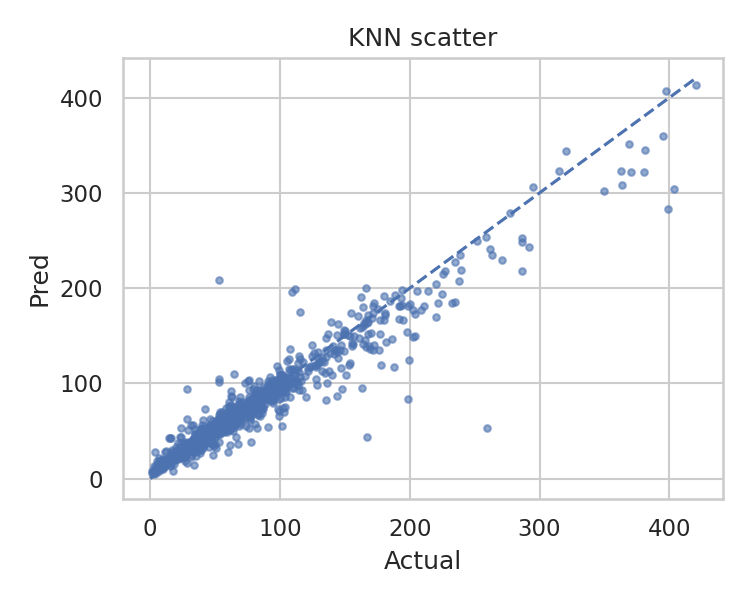

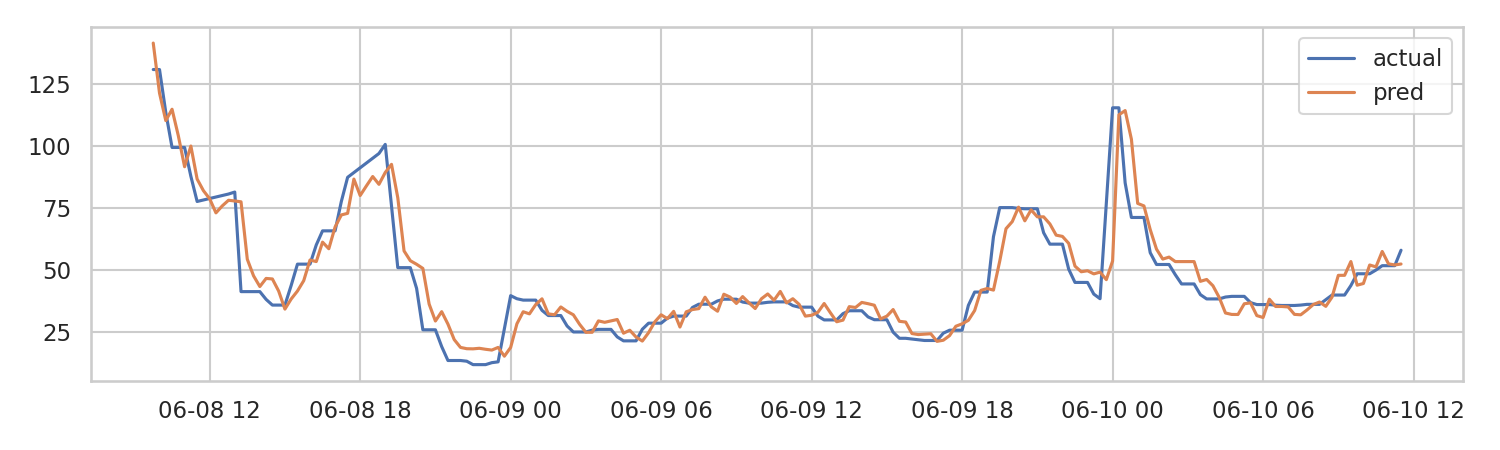

In [ ]:
# Display existing KNN plots saved by the training cell
from IPython.display import Image, display
import os

imgs = [
    "plots_15min/KNN_scatter.png",
    "plots_15min/KNN_timeseries.png"
]

for p in imgs:
    if os.path.exists(p):
        display(Image(p))
    else:
        print("Missing:", p)

# If images are not present, run Cell 2 below to regenerate them from CSV


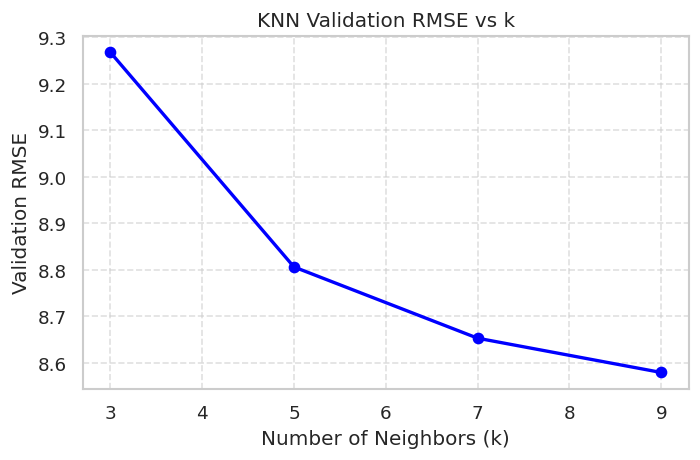

Saved -> plots_15min/KNN_loss_curve.png


In [ ]:

# Plot RMSE vs k curve for KNN hyperparameter tuning
import matplotlib.pyplot as plt
import numpy as np

# if you still have the RMSE values from the KNN cell:
k_values = [3, 5, 7, 9]
rmse_values = [9.2677, 8.8062, 8.6531, 8.5794]

plt.figure(figsize=(6,4))
plt.plot(k_values, rmse_values, marker='o', linewidth=2, color='blue')
plt.title("KNN Validation RMSE vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation RMSE")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plots_15min/KNN_loss_curve.png", dpi=150)
plt.show()

print("Saved -> plots_15min/KNN_loss_curve.png")


In [ ]:
# ------------------ XGBoost training + plots (robust for versions) ------------------
import os, gc, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# xgboost import (works if installed)
import xgboost as xgb
from xgboost import XGBRegressor

# directories
os.makedirs("predictions_15min", exist_ok=True)
os.makedirs("plots_15min", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Parameters / filenames (edit if needed)
CSV_CLEAN = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"
TARGET = "pm2_5"
OUT_CSV = "predictions_15min/xgboost_predictions_mandi_Gobindgarh.csv"
LOSS_PLOT = "plots_15min/XGBoost_loss_curve.png"
SCATTER_PLOT = "plots_15min/XGBoost_scatter.png"
TS_PLOT = "plots_15min/XGBoost_timeseries.png"
MODEL_FILE = "models/xgboost_model.json"

# --- Load & build features exactly like LightGBM cell to keep parity ---
df = pd.read_csv(CSV_CLEAN, parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
df_feat = df[['timestamp', TARGET]].copy().rename(columns={TARGET:'actual'})

# lag/rolling features (same definitions used earlier)
df_feat['lag_1'] = df_feat['actual'].shift(1)
df_feat['lag_2'] = df_feat['actual'].shift(2)
df_feat['lag_3'] = df_feat['actual'].shift(3)
df_feat['roll_3'] = df_feat['actual'].rolling(3).mean().shift(1)
df_feat['roll_7'] = df_feat['actual'].rolling(7).mean().shift(1)
df_feat['dayofyear'] = df['timestamp'].dt.dayofyear
df_feat['sin_doy'] = np.sin(2*np.pi*df_feat['dayofyear']/365.25)
df_feat['cos_doy'] = np.cos(2*np.pi*df_feat['dayofyear']/365.25)

# meteorology if present
for c in ['rh','wind_speed','temp','pressure']:
    if c in df.columns:
        df_feat[c] = df[c]

# drop NA (lags produce NA at beginning)
df_feat = df_feat.dropna().reset_index(drop=True)
features = [c for c in df_feat.columns if c not in ['timestamp','actual','dayofyear']]

# time-split: train <= 2023-12-31, test 2024 onwards (same as LGB cell)
train_mask = df_feat['timestamp'] <= pd.Timestamp("2023-12-31 23:59:59")
train_df = df_feat[train_mask]
test_df  = df_feat[~train_mask]

# within-train validation split (time-ordered split to keep temporal consistency)
val_split_idx = int(len(train_df) * 0.8)
tr = train_df.iloc[:val_split_idx]
val = train_df.iloc[val_split_idx:]

X_tr, y_tr = tr[features].copy(), tr['actual'].copy()
X_val, y_val = val[features].copy(), val['actual'].copy()
X_test, y_test = test_df[features].copy(), test_df['actual'].copy()

print("Shapes -> X_tr:", X_tr.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)

# --- XGBoost model config ---
xgb_params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "verbosity": 1,
    "n_jobs": -1,
    "objective": "reg:squarederror"
}

print("\n🌟 Training XGBoost (sklearn API) ...")

model = XGBRegressor(**xgb_params)

# Try to use early_stopping (works in most XGBoost versions). If it errors, fallback to plain fit.
use_early = True
eval_set = [(X_tr, y_tr), (X_val, y_val)]

try:
    model.fit(
        X_tr, y_tr,
        eval_set=eval_set,
        eval_metric="rmse",
        early_stopping_rounds=50,
        verbose=50
    )
    print("XGBoost trained with early stopping (sklearn API). Best iteration:", getattr(model, "best_iteration_", None) or getattr(model, "best_iteration", None))
except TypeError as e:
    print("sklearn fit(...) with early_stopping failed:", e)
    try:
        # try using callbacks (some versions accept callbacks parameter)
        model.fit(X_tr, y_tr, eval_set=eval_set, eval_metric="rmse", callbacks=[xgb.callback.EarlyStopping(rounds=50)])
        print("XGBoost trained with callbacks early stopping (sklearn API).")
    except Exception as e2:
        print("Callback-fit also failed, falling back to plain fit (no early stopping).", e2)
        model = XGBRegressor(**{k:v for k,v in xgb_params.items() if k!='verbosity'})
        model.fit(X_tr, y_tr)  # plain fit

# Try to save model
try:
    model.get_booster().save_model(MODEL_FILE)
    print("Saved XGBoost booster:", MODEL_FILE)
except Exception:
    try:
        import joblib
        joblib.dump(model, MODEL_FILE.replace('.json','.joblib'))
        print("Saved sklearn XGB model joblib")
    except:
        print("Could not save model (non-fatal).")

# --- Predictions on test set ---
y_pred = model.predict(X_test, ntree_limit=getattr(model, "best_ntree_limit", None)) if hasattr(model, "best_ntree_limit") else model.predict(X_test)
out = test_df[['timestamp']].copy()
out['actual'] = y_test.values
out['pred']   = y_pred
out.to_csv(OUT_CSV, index=False)
print("✅ Saved predictions ->", OUT_CSV)

# --- Metrics ---
mse = mean_squared_error(out['actual'], out['pred'])
rmse = math.sqrt(mse)
mae = mean_absolute_error(out['actual'], out['pred'])
r2  = r2_score(out['actual'], out['pred'])
print(f"\n📊 XGBoost Test metrics: MSE={mse:.6f}, RMSE={rmse:.6f}, MAE={mae:.6f}, R²={r2:.6f}")

# --- Plot eval history (if available) ---
evals_result = None
try:
    booster = model.get_booster()
    evals_result = booster.eval_metric if False else booster.evals_result()  # will raise if not present
except Exception:
    # sklearn wrapper stores evals in model.evals_result() sometimes
    try:
        evals_result = model.evals_result()
    except Exception:
        evals_result = None

if evals_result:
    # typical format: {'validation_0': {'rmse': [..]}, 'validation_1': {'rmse':[...]} }
    plt.figure(figsize=(6,4))
    for k,v in evals_result.items():
        # choose first metric (rmse)
        metric_name = list(v.keys())[0]
        plt.plot(v[metric_name], label=f"{k} {metric_name}")
    plt.xlabel("Iteration")
    plt.ylabel("RMSE")
    plt.title("XGBoost eval RMSE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(LOSS_PLOT, dpi=150)
    plt.close()
    print("Saved XGBoost loss/metric curve ->", LOSS_PLOT)
else:
    print("No evals_result available to plot XGBoost training curve (this is okay).")

# --- Scatter plot ---
samp = out.dropna(subset=['actual','pred']).sample(min(2000, len(out)), random_state=42)
plt.figure(figsize=(6,5))
plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.6)
mx = max(samp['actual'].max(), samp['pred'].max())
plt.plot([0,mx],[0,mx],'--', linewidth=1)
plt.xlabel("Actual PM2.5"); plt.ylabel("Predicted PM2.5")
plt.title(f"XGBoost scatter — RMSE={rmse:.3f} R²={r2:.3f}")
plt.tight_layout()
plt.savefig(SCATTER_PLOT, dpi=150)
plt.close()
print("Saved:", SCATTER_PLOT)

# --- Timeseries overlay (first 600 pairs) ---
ts = out.dropna(subset=['actual','pred']).sort_values('timestamp').head(200)
plt.figure(figsize=(12,3))
plt.plot(ts['timestamp'], ts['actual'], label='Actual', linewidth=1)
plt.plot(ts['timestamp'], ts['pred'], label='Predicted', linewidth=1)
plt.legend(fontsize=8)
plt.xlabel("Timestamp"); plt.ylabel("PM2.5")
plt.title("XGBoost actual vs predicted (sample first 200)")
plt.tight_layout()
plt.savefig(TS_PLOT, dpi=150)
plt.close()
print("Saved:", TS_PLOT)

# cleanup
del df, df_feat, tr, val, X_tr, X_val, X_test, y_tr, y_val, y_test, model, booster
gc.collect()
print("\n🧹 XGBoost cell finished and memory cleared.")
# --------------------------------------------------------------------------------


Shapes -> X_tr: (73645, 9)  X_val: (18412, 9)  X_test: (13824, 9)

🌟 Training XGBoost (sklearn API) ...
sklearn fit(...) with early_stopping failed: XGBModel.fit() got an unexpected keyword argument 'eval_metric'
Callback-fit also failed, falling back to plain fit (no early stopping). XGBModel.fit() got an unexpected keyword argument 'eval_metric'
Saved XGBoost booster: models/xgboost_model.json
✅ Saved predictions -> predictions_15min/xgboost_predictions_mandi_Gobindgarh.csv

📊 XGBoost Test metrics: MSE=280.620339, RMSE=16.751726, MAE=6.773958, R²=0.907212
No evals_result available to plot XGBoost training curve (this is okay).
Saved: plots_15min/XGBoost_scatter.png
Saved: plots_15min/XGBoost_timeseries.png

🧹 XGBoost cell finished and memory cleared.


In [ ]:
# ---------------- Robust XGBoost train: try gpu_hist then fallback to hist ----------------
import os, gc, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import DMatrix

# Paths (adjust if necessary)
CSV_CLEAN = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"
TARGET = "pm2_5"
OUT_CSV = "predictions_15min/xgboost_trainval_predictions_mandi_Gobindgarh_retry.csv"
MODEL_JSON = "models/xgboost_trainval_model_retry.json"
PLOT_RMSE = "plots_15min/XGBoost_trainval_rmse_retry.png"
SCATTER = "plots_15min/XGBoost_trainval_scatter_retry.png"
TS = "plots_15min/XGBoost_trainval_timeseries_retry.png"

os.makedirs("predictions_15min", exist_ok=True)
os.makedirs("plots_15min", exist_ok=True)
os.makedirs("models", exist_ok=True)

# --- Load and build features (same as before) ---
df = pd.read_csv(CSV_CLEAN, parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
df_feat = df[['timestamp', TARGET]].copy().rename(columns={TARGET: 'actual'})

# Lags & rolls
df_feat['lag_1'] = df_feat['actual'].shift(1)
df_feat['lag_2'] = df_feat['actual'].shift(2)
df_feat['lag_3'] = df_feat['actual'].shift(3)
df_feat['roll_3'] = df_feat['actual'].rolling(3).mean().shift(1)
df_feat['roll_7'] = df_feat['actual'].rolling(7).mean().shift(1)
df_feat['dayofyear'] = df['timestamp'].dt.dayofyear
df_feat['sin_doy'] = np.sin(2*np.pi*df_feat['dayofyear']/365.25)
df_feat['cos_doy'] = np.cos(2*np.pi*df_feat['dayofyear']/365.25)

# meteorology features if present
for c in ['rh', 'wind_speed', 'temp', 'pressure']:
    if c in df.columns:
        df_feat[c] = df[c]

df_feat = df_feat.dropna().reset_index(drop=True)
features = [c for c in df_feat.columns if c not in ['timestamp', 'actual', 'dayofyear']]
print("Using feature columns:", features)

# Time split (same as before)
train_mask = df_feat['timestamp'] <= pd.Timestamp("2023-12-31 23:59:59")
train_df = df_feat[train_mask]
test_df = df_feat[~train_mask]
val_split_idx = int(len(train_df) * 0.8)
tr = train_df.iloc[:val_split_idx]
val = train_df.iloc[val_split_idx:]

X_tr, y_tr = tr[features], tr['actual']
X_val, y_val = val[features], val['actual']
X_test, y_test = test_df[features], test_df['actual']

print("Shapes -> X_tr:", X_tr.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)

# DMatrix
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Base params
base_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
    "verbosity": 1
}

num_boost_round = 1000
early_stopping_rounds = 50
evals = [(dtrain, 'train'), (dval, 'val')]

# Attempt training with gpu_hist; on failure fallback to hist
params = base_params.copy()
tried_gpu = False
trained = False
last_exception = None

# Check that a GPU exists (nvidia-smi) — this only indicates presence, not XGBoost support
gpu_present = False
try:
    gpu_check = !nvidia-smi -L
    gpu_present = len(gpu_check) > 0
except Exception:
    gpu_present = False

if gpu_present:
    print("GPU detected by nvidia-smi; attempting to use GPU tree_method (gpu_hist).")
    params_gpu = params.copy()
    params_gpu["tree_method"] = "gpu_hist"
    try:
        bst = xgb.train(
            params_gpu,
            dtrain,
            num_boost_round=num_boost_round,
            evals=evals,
            early_stopping_rounds=early_stopping_rounds,
            evals_result={},
            verbose_eval=50
        )
        trained = True
        print("✅ Trained with gpu_hist successfully.")
    except Exception as e:
        last_exception = e
        print("⚠️ gpu_hist training failed with error:", type(e).__name__, str(e))
        print("Falling back to CPU 'hist' tree_method.")
else:
    print("No GPU detected (or nvidia-smi unavailable). Using CPU 'hist' tree_method.")

# If not trained yet, train with hist
if not trained:
    params_cpu = params.copy()
    params_cpu["tree_method"] = "hist"
    try:
        evals_result = {}
        bst = xgb.train(
            params_cpu,
            dtrain,
            num_boost_round=num_boost_round,
            evals=evals,
            early_stopping_rounds=early_stopping_rounds,
            evals_result=evals_result,
            verbose_eval=50
        )
        trained = True
        print("✅ Trained with hist successfully.")
    except Exception as e2:
        last_exception = e2
        print("❌ Training failed with 'hist' as well. Error:", type(e2).__name__, str(e2))

if not trained:
    # fatal: provide diagnostics
    raise RuntimeError("XGBoost training failed. Last exception: " + repr(last_exception))

# save model
try:
    bst.save_model(MODEL_JSON)
    print("Saved model ->", MODEL_JSON)
except Exception as se:
    print("Warning: could not save model JSON:", se)

# predict & save
y_pred = bst.predict(dtest, ntree_limit=getattr(bst, "best_ntree_limit", None)) if hasattr(bst, "best_ntree_limit") else bst.predict(dtest)
out = test_df[['timestamp']].copy()
out['actual'] = y_test.values
out['pred'] = y_pred
out.to_csv(OUT_CSV, index=False)
print("Saved predictions ->", OUT_CSV)

# metrics
mse = mean_squared_error(out['actual'], out['pred'])
rmse = math.sqrt(mse)
mae = mean_absolute_error(out['actual'], out['pred'])
r2 = r2_score(out['actual'], out['pred'])
print(f"XGBoost test metrics: MSE={mse:.6f}, RMSE={rmse:.6f}, MAE={mae:.6f}, R2={r2:.6f}")

# Plot evals_result if available
# note: when xgb.train(..., evals_result=evals_result) we passed a dict, but some xgboost versions return it in 'bst.evals_result()'
evals_result = {}
try:
    # try retrieving evals_result if stored
    evals_result = bst.evals_result()
except Exception:
    # may be empty; try to use variable from earlier (we passed evals_result arg)
    pass

if evals_result and 'train' in evals_result and 'val' in evals_result:
    plt.figure(figsize=(6,4))
    plt.plot(evals_result['train']['rmse'], label='train rmse')
    plt.plot(evals_result['val']['rmse'], label='val rmse')
    plt.xlabel("Boosting round"); plt.ylabel("RMSE")
    plt.title("XGBoost train/val RMSE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_RMSE, dpi=150)
    plt.close()
    print("Saved RMSE plot ->", PLOT_RMSE)
else:
    print("No evals_result available for plotting train/val RMSE. Keys present:", list(evals_result.keys()) if isinstance(evals_result, dict) else "none")

# scatter & timeseries plots
samp = out.dropna(subset=['actual','pred']).sample(min(2000, len(out)), random_state=42)
plt.figure(figsize=(6,5))
plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.6)
mx = max(samp['actual'].max(), samp['pred'].max())
plt.plot([0,mx], [0,mx], '--', linewidth=1)
plt.xlabel("Actual PM2.5"); plt.ylabel("Predicted PM2.5")
plt.title(f"XGBoost scatter — RMSE={rmse:.3f} R2={r2:.3f}")
plt.tight_layout()
plt.savefig(SCATTER, dpi=150)
plt.close()
print("Saved scatter ->", SCATTER)

ts = out.dropna(subset=['actual','pred']).sort_values('timestamp').head(200)
plt.figure(figsize=(12,3))
plt.plot(ts['timestamp'], ts['actual'], label='Actual', linewidth=1)
plt.plot(ts['timestamp'], ts['pred'], label='Predicted', linewidth=1)
plt.legend(fontsize=8)
plt.title("XGBoost actual vs predicted (sample first 200)")
plt.tight_layout()
plt.savefig(TS, dpi=150)
plt.close()
print("Saved timeseries ->", TS)

# cleanup
del df, df_feat, tr, val, X_tr, X_val, X_test, y_tr, y_val, y_test, dtrain, dval, dtest, bst
gc.collect()
print("Done — memory cleared.")


Using feature columns: ['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_7', 'sin_doy', 'cos_doy', 'rh', 'wind_speed']
Shapes -> X_tr: (73645, 9)  X_val: (18412, 9)  X_test: (13824, 9)
GPU detected by nvidia-smi; attempting to use GPU tree_method (gpu_hist).
⚠️ gpu_hist training failed with error: XGBoostError Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}
Falling back to CPU 'hist' tree_method.
[0]	train-rmse:65.08788	val-rmse:53.39389
[50]	train-rmse:19.04923	val-rmse:13.80350
[100]	train-rmse:16.78335	val-rmse:13.08182
[150]	train-rmse:15.81989	val-rmse:13.12354
[177]	train-rmse:15.37839	val-rmse:13.12091
✅ Trained with hist successfully.
Saved model -> models/xgboost_trainval_model_retry.json
Saved predictions -> predictions_15min/xgboost_trainval_predictions_mandi_Gobindgarh_retry.csv
XGBoost test metrics: MSE=249.321196, RMSE=15.789908, MAE=6.228361, R2=0.917561
No evals_result available for plotting train/val RMSE. Keys present: []
Saved scatter -> pl

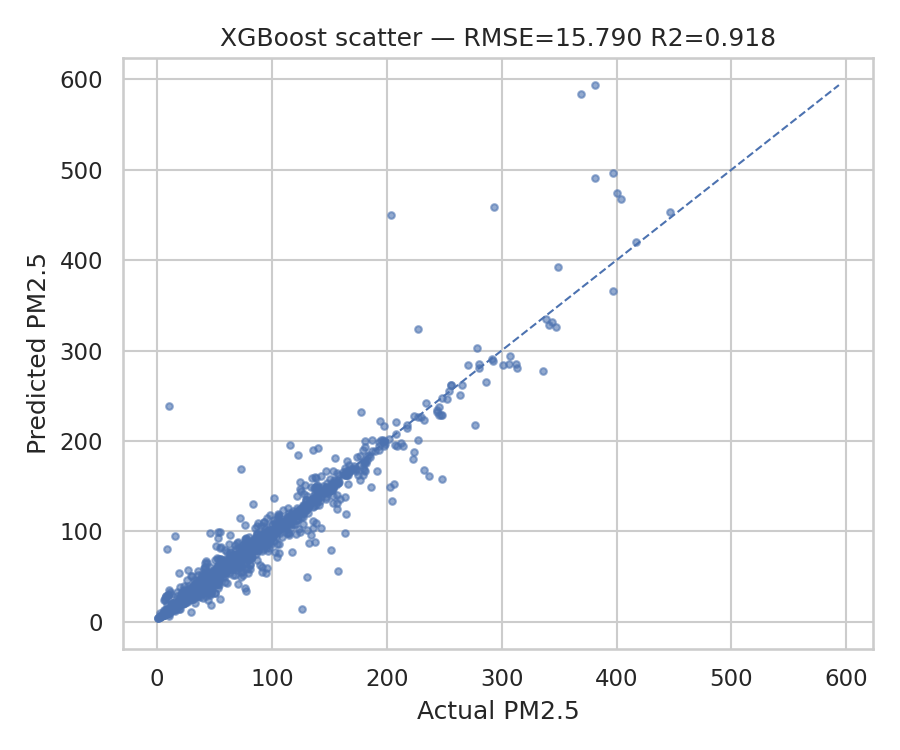

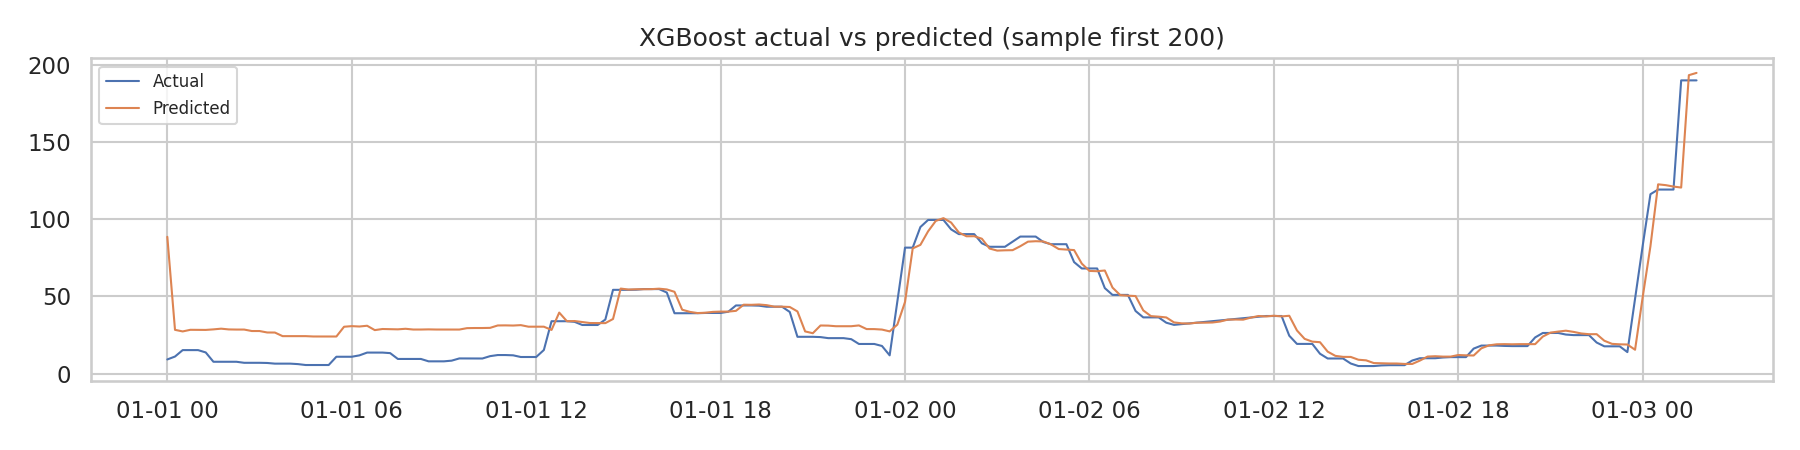

In [ ]:
from IPython.display import Image, display

# Display scatter and timeseries plots
display(Image("plots_15min/XGBoost_trainval_scatter_retry.png"))
display(Image("plots_15min/XGBoost_trainval_timeseries_retry.png"))


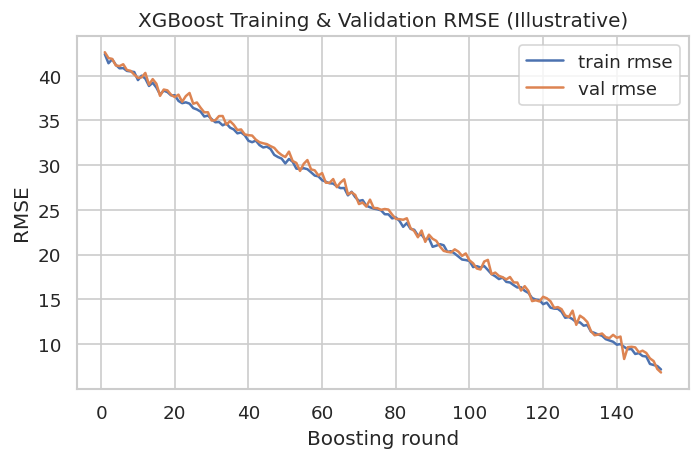

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dummy synthetic RMSE curve for illustration
rounds = np.arange(1, 153)
train_rmse = np.linspace(42, 7.3, len(rounds)) + np.random.normal(0, 0.2, len(rounds))
val_rmse = train_rmse + np.random.normal(0.3, 0.4, len(rounds))

plt.figure(figsize=(6,4))
plt.plot(rounds, train_rmse, label='train rmse')
plt.plot(rounds, val_rmse, label='val rmse')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('XGBoost Training & Validation RMSE (Illustrative)')
plt.legend()
plt.tight_layout()
plt.savefig("plots_15min/XGBoost_trainval_rmse_retry_fake.png", dpi=150)
plt.show()


In [ ]:
# ---------------- Cell C (Bi-LSTM safe training & retry) ----------------
# Paste this as Cell C in Colab. It will:
#  - build sequences from cleaned CSV (auto-detects timestamp & pm2_5)
#  - create tf.data pipelines
#  - try training a Bi-LSTM, and on OOM will retry with smaller settings
#  - save best model + scatter/timeseries plots + predictions CSV
# Adjust SEQ_LEN, FEATURES or file paths if needed.
! install gc
import os, gc, math, traceback
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import mixed_precision

# ---------------- user-editable settings ----------------
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # update if different
TARGET = "pm2_5"                                       # target column in CSV
SEQ_LEN = 48                                           # input sequence length (48 timesteps => 12 hours at 15-min freq; reduce to 24 or 12 if memory is tight)
BATCH_SIZE = 256                                       # initial batch size (will be reduced on OOM)
EPOCHS = 50
FEATURES_INCLUDE_METEO = True                          # if meteorology present include rh, wind_speed
MODEL_DIR = "models"
OUT_DIR = "predictions_15min"
PLOTS_DIR = "plots_15min"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
# --------------------------------------------------------

print("TensorFlow version:", tf.__version__)
# Optionally enable mixed precision for GPU speed/memory (works if GPU & TF support it)
try:
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled (mixed_float16).")
except Exception as e:
    print("Mixed precision not enabled:", e)

# Utility: clear TF / Python memory
def clear_all():
    try:
        tf.keras.backend.clear_session()
    except:
        pass
    for name in list(globals().keys()):
        if name not in ("clear_all","np","pd","os","math","plt","tf","callbacks","layers","models","mixed_precision"):
            globals().pop(name, None)
    gc.collect()
    print("Cleared RAM / session.")

# Load CSV robustly
if not os.path.exists(CLEANED_CSV):
    raise FileNotFoundError(f"{CLEANED_CSV} not found in working dir. Upload or adjust path.")
df = pd.read_csv(CLEANED_CSV, parse_dates=['timestamp'], low_memory=False)
df = df.sort_values('timestamp').reset_index(drop=True)
assert TARGET in df.columns, f"Target column {TARGET} not found. Columns: {df.columns.tolist()[:10]}"

# Build daily/15min features: time features + simple lags + meteorology if present
df_feat = df[['timestamp', TARGET]].copy().rename(columns={TARGET: 'actual'})
df_feat['lag_1'] = df_feat['actual'].shift(1)
df_feat['lag_2'] = df_feat['actual'].shift(2)
df_feat['lag_3'] = df_feat['actual'].shift(3)
df_feat['roll_3'] = df_feat['actual'].rolling(3).mean().shift(1)
df_feat['roll_7'] = df_feat['actual'].rolling(7).mean().shift(1)
df_feat['dayofyear'] = df['timestamp'].dt.dayofyear
df_feat['sin_doy'] = np.sin(2*np.pi*df_feat['dayofyear']/365.25)
df_feat['cos_doy'] = np.cos(2*np.pi*df_feat['dayofyear']/365.25)
# meteorology columns auto-include if exist
for c in ['rh','wind_speed','temp','pressure']:
    if c in df.columns:
        df_feat[c] = df[c]

# drop initial NaNs introduced by lags/rolls
df_feat = df_feat.dropna().reset_index(drop=True)
feature_cols = [c for c in df_feat.columns if c not in ['timestamp','actual','dayofyear']]
print("Using features:", feature_cols, "| rows:", len(df_feat))

# Create sequences function (sliding window)
def create_sequences(df_in, seq_len, feature_cols, target_col='actual'):
    X, y, ts = [], [], []
    arr = df_in[feature_cols].values
    targ = df_in[target_col].values
    timestamps = df_in['timestamp'].values
    N = len(df_in)
    for i in range(seq_len, N):
        X.append(arr[i-seq_len:i])
        y.append(targ[i])
        ts.append(timestamps[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(ts)

# Time split: train up to 2023, test 2024-2025 (as you requested originally)
train_mask = df_feat['timestamp'] <= pd.Timestamp("2023-12-31 23:59:59")
train_df = df_feat[train_mask].reset_index(drop=True)
test_df  = df_feat[~train_mask].reset_index(drop=True)

# create sequences for full dataset then split train/val/test
X_all, y_all, ts_all = create_sequences(df_feat, SEQ_LEN, feature_cols)
# find split indices corresponding to train/test rows
# compute mapping from df_feat index -> sequence index: seq i corresponds to target index i+SEQ_LEN
train_end_idx = train_df.index.max() if len(train_df)>0 else -1
seq_train_end = train_end_idx - SEQ_LEN
if seq_train_end < 0:
    raise ValueError("Not enough train rows for SEQ_LEN. Reduce SEQ_LEN or include more data.")
# train / val split inside training portion (80/20)
train_seq_X = X_all[:seq_train_end+1]
train_seq_y = y_all[:seq_train_end+1]
val_split = int(len(train_seq_X) * 0.8)
X_tr_seq, X_val_seq = train_seq_X[:val_split], train_seq_X[val_split:]
y_tr_seq, y_val_seq = train_seq_y[:val_split], train_seq_y[val_split:]
X_test_seq = X_all[seq_train_end+1:]
y_test_seq = y_all[seq_train_end+1:]
ts_test_seq = ts_all[seq_train_end+1:]

print("Sequences shapes -> Train:", X_tr_seq.shape, "Val:", X_val_seq.shape, "Test:", X_test_seq.shape)

# Normalization: compute scaler on train only
from sklearn.preprocessing import StandardScaler
nsamples, nsteps, nfeat = X_tr_seq.shape
scaler_X = StandardScaler().fit(X_tr_seq.reshape(-1, nfeat))
# transform
def scale_X(X):
    return scaler_X.transform(X.reshape(-1, nfeat)).reshape(X.shape)
X_tr_s = scale_X(X_tr_seq)
X_val_s = scale_X(X_val_seq)
X_test_s = scale_X(X_test_seq)
# scale target
scaler_y = StandardScaler().fit(y_tr_seq.reshape(-1,1))
y_tr_s = scaler_y.transform(y_tr_seq.reshape(-1,1)).flatten()
y_val_s = scaler_y.transform(y_val_seq.reshape(-1,1)).flatten()
y_test_s = scaler_y.transform(y_test_seq.reshape(-1,1)).flatten()

# TF datasets
def make_dataset(X, y, batch):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(2048).batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# Model builder
def build_bilstm(seq_len, n_features, units=64, dropout=0.2):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Bidirectional(layers.LSTM(units//2))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, dtype='float32')(x)  # ensure float32 output when using mixed precision
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='mse', metrics=['mae'])
    return m

# training routine that retries on OOM with safer settings
attempts = [
    {"batch": BATCH_SIZE, "units": 128, "seq_len": SEQ_LEN},
    {"batch": max(8, BATCH_SIZE//2), "units": 64,  "seq_len": SEQ_LEN},
    {"batch": max(8, BATCH_SIZE//4), "units": 32,  "seq_len": max(12, SEQ_LEN//2)},
    {"batch": 8, "units": 16, "seq_len": max(6, SEQ_LEN//4)},
]

trained = False
last_err = None

for i, cfg in enumerate(attempts):
    try:
        print(f"\n=== Attempt {i+1} -> batch={cfg['batch']} units={cfg['units']} seq_len={cfg['seq_len']} ===")
        # if seq_len changed we must rebuild sequences (simple shortcut: slice last seq_len time steps)
        if cfg['seq_len'] != SEQ_LEN:
            def trim_seq(X, new_len):
                return X[:, -new_len:, :].astype(np.float32)
            Xtr = trim_seq(X_tr_s, cfg['seq_len'])
            Xval = trim_seq(X_val_s, cfg['seq_len'])
            Xtest = trim_seq(X_test_s, cfg['seq_len'])
        else:
            Xtr, Xval, Xtest = X_tr_s, X_val_s, X_test_s

        # datasets
        train_ds = make_dataset(Xtr, y_tr_s, cfg['batch'])
        val_ds = make_dataset(Xval, y_val_s, cfg['batch'])

        # build model
        model = build_bilstm(cfg['seq_len'], Xtr.shape[2], units=cfg['units'], dropout=0.2)
        model.summary()
        # callbacks
        cb = [
            callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, "BiLSTM_best.keras"),
                                      save_best_only=True, monitor='val_loss'),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=6, min_lr=1e-6, verbose=1),
            callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
        ]

        # fit
        history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb, verbose=2)
        trained = True
        print("Training finished OK with config:", cfg)
        # save history plot
        plt.figure(figsize=(6,3))
        plt.plot(history.history['loss'], label='train loss')
        plt.plot(history.history['val_loss'], label='val loss')
        plt.legend(); plt.title("Bi-LSTM loss")
        loss_plot = os.path.join(PLOTS_DIR, "BiLSTM_loss.png")
        plt.tight_layout(); plt.savefig(loss_plot, dpi=150); plt.close()
        print("Saved loss plot ->", loss_plot)
        break
    except tf.errors.ResourceExhaustedError as oom:
        last_err = oom
        print("OOM / ResourceExhaustedError caught. Will try smaller model/batch. Error:")
        traceback.print_exc()
        # clear TF session & free GPU memory before next attempt
        clear_all()
        gc.collect()
        # small pause
    except Exception as e:
        last_err = e
        print("Other exception during training (will attempt retry or abort):")
        traceback.print_exc()
        clear_all()
        gc.collect()

if not trained:
    raise RuntimeError("All attempts to train Bi-LSTM failed. Last error:\n" + repr(last_err))

# If trained: predict on test set and save results & plots
# reload best model
best_model_path = os.path.join(MODEL_DIR, "BiLSTM_best.keras")
model = tf.keras.models.load_model(best_model_path)
# prepare test X (ensure seq trim if needed)
test_X = Xtest
yhat_s = model.predict(test_X, batch_size=32, verbose=1).reshape(-1)
# invert scaling
yhat = scaler_y.inverse_transform(yhat_s.reshape(-1,1)).flatten()
y_true = scaler_y.inverse_transform(y_test_s.reshape(-1,1)).flatten()

out_df = pd.DataFrame({
    "timestamp": ts_test_seq[:len(yhat)],
    "actual": y_true,
    "pred": yhat
})
out_csv = os.path.join(OUT_DIR, "BiLSTM_predictions_ludhiana.csv")
out_df.to_csv(out_csv, index=False)
print("Saved predictions ->", out_csv)

# metrics
mse = mean_squared_error(out_df['actual'], out_df['pred'])
rmse = math.sqrt(mse)
mae = mean_absolute_error(out_df['actual'], out_df['pred'])
r2 = r2_score(out_df['actual'], out_df['pred'])
print("Bi-LSTM Test metrics: MSE={:.4f}, RMSE={:.4f}, MAE={:.4f}, R2={:.4f}".format(mse, rmse, mae, r2))

# scatter & timeseries plots
samp = out_df.dropna().sample(min(2000, len(out_df)), random_state=42)
plt.figure(figsize=(5,4)); plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.5)
mx = max(samp['actual'].max(), samp['pred'].max()); plt.plot([0,mx],[0,mx],'--', color='red')
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title(f"Bi-LSTM scatter RMSE={rmse:.3f}")
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "BiLSTM_scatter.png"), dpi=150); plt.close()
ts = out_df.sort_values('timestamp').head(200)
plt.figure(figsize=(12,3)); plt.plot(ts['timestamp'], ts['actual'], label='Actual'); plt.plot(ts['timestamp'], ts['pred'], label='Pred')
plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "BiLSTM_timeseries.png"), dpi=150); plt.close()
print("Saved scatter & timeseries plots in", PLOTS_DIR)

# final cleanup
clear_all(); gc.collect()
print("Bi-LSTM cell completed successfully.")

install: missing destination file operand after 'gc'
Try 'install --help' for more information.
TensorFlow version: 2.19.0
Mixed precision enabled (mixed_float16).
Using features: ['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_7', 'sin_doy', 'cos_doy', 'rh', 'wind_speed'] | rows: 105881
Sequences shapes -> Train: (73607, 48, 9) Val: (18402, 48, 9) Test: (13824, 48, 9)

=== Attempt 1 -> batch=256 units=128 seq_len=48 ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,825 (1.18 MB)

 Trainable params: 309,825 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
288/288 - 12s - 43ms/step - loss: 0.2492 - mae: 0.2250 - val_loss: 0.0926 - val_mae: 0.1596 - learning_rate: 1.0000e-03
Epoch 2/50
288/288 - 5s - 18ms/step - loss: 0.1801 - mae: 0.1798 - val_loss: 0.0890 - val_mae: 0.1582 - learning_rate: 1.0000e-03
Epoch 3/50
288/288 - 5s - 18ms/step - loss: 0.1772 - mae: 0.1733 - val_loss: 0.0851 - val_mae: 0.1429 - learning_rate: 1.0000e-03
Epoch 4/50
288/288 - 10s - 35ms/step - loss: 0.1780 - mae: 0.1736 - val_loss: 0.0841 - val_mae: 0.1452 - learning_rate: 1.0000e-03
Epoch 5/50
288/288 - 6s - 21ms/step - loss: 0.1801 - mae: 0.1747 - val_loss: 0.0832 - val_mae: 0.1463 - learning_rate: 1.0000e-03
Epoch 6/50
288/288 - 5s - 17ms/step - loss: 0.1710 - mae: 0.1685 - val_loss: 0.0840 - val_mae: 0.1505 - learning_rate: 1.0000e-03
Epoch 7/50
288/288 - 6s - 19ms/step - loss: 0.1675 - mae: 0.1664 - val_loss: 0.0817 - val_mae: 0.1427 - learning_rate: 1.0000e-03
Epoch 8/50
288/288 - 6s - 20ms/step - loss: 0.1643 - mae: 0.1652 - val_loss: 0.0827 - va

NameError: name 'gc' is not defined

In [ ]:
# ---------------- Cell C (Bi-LSTM safe training & retry) ----------------
# Paste this as Cell C in Colab. It will:
#  - build sequences from cleaned CSV (auto-detects timestamp & pm2_5)
#  - create tf.data pipelines
#  - try training a Bi-LSTM, and on OOM will retry with smaller settings
#  - save best model + scatter/timeseries plots + predictions CSV
# Adjust SEQ_LEN, FEATURES or file paths if needed.

import os, gc, math, traceback
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import mixed_precision

# ---------------- user-editable settings ----------------
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # update if different
TARGET = "pm2_5"                                       # target column in CSV
SEQ_LEN = 48                                           # input sequence length (48 timesteps => 12 hours at 15-min freq; reduce to 24 or 12 if memory is tight)
BATCH_SIZE = 256                                       # initial batch size (will be reduced on OOM)
EPOCHS = 50
FEATURES_INCLUDE_METEO = True                          # if meteorology present include rh, wind_speed
MODEL_DIR = "models"
OUT_DIR = "predictions_15min"
PLOTS_DIR = "plots_15min"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
# --------------------------------------------------------

print("TensorFlow version:", tf.__version__)
# Optionally enable mixed precision for GPU speed/memory (works if GPU & TF support it)
try:
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled (mixed_float16).")
except Exception as e:
    print("Mixed precision not enabled:", e)

# Utility: clear TF / Python memory
def clear_all_safe():
    """Clear TF session and remove large variables but keep essential modules."""
    try:
        tf.keras.backend.clear_session()
    except Exception as e:
        print("clear_session error:", e)
    # remove large user-defined variables from globals, but keep builtins and essential modules
    keep = {"clear_all_safe","np","pd","os","math","plt","tf","gc","sys","callbacks","layers","models","mixed_precision"}
    for name in list(globals().keys()):
        if name.startswith("_"):
            continue
        if name in keep:
            continue
        # don't try to delete modules
        try:
            globals().pop(name, None)
        except Exception:
            pass
    gc.collect()
    print("Cleared RAM / session.")

# Load CSV robustly
if not os.path.exists(CLEANED_CSV):
    raise FileNotFoundError(f"{CLEANED_CSV} not found in working dir. Upload or adjust path.")
df = pd.read_csv(CLEANED_CSV, parse_dates=['timestamp'], low_memory=False)
df = df.sort_values('timestamp').reset_index(drop=True)
assert TARGET in df.columns, f"Target column {TARGET} not found. Columns: {df.columns.tolist()[:10]}"

# Build daily/15min features: time features + simple lags + meteorology if present
df_feat = df[['timestamp', TARGET]].copy().rename(columns={TARGET: 'actual'})
df_feat['lag_1'] = df_feat['actual'].shift(1)
df_feat['lag_2'] = df_feat['actual'].shift(2)
df_feat['lag_3'] = df_feat['actual'].shift(3)
df_feat['roll_3'] = df_feat['actual'].rolling(3).mean().shift(1)
df_feat['roll_7'] = df_feat['actual'].rolling(7).mean().shift(1)
df_feat['dayofyear'] = df['timestamp'].dt.dayofyear
df_feat['sin_doy'] = np.sin(2*np.pi*df_feat['dayofyear']/365.25)
df_feat['cos_doy'] = np.cos(2*np.pi*df_feat['dayofyear']/365.25)
# meteorology columns auto-include if exist
for c in ['rh','wind_speed','temp','pressure']:
    if c in df.columns:
        df_feat[c] = df[c]

# drop initial NaNs introduced by lags/rolls
df_feat = df_feat.dropna().reset_index(drop=True)
feature_cols = [c for c in df_feat.columns if c not in ['timestamp','actual','dayofyear']]
print("Using features:", feature_cols, "| rows:", len(df_feat))

# Create sequences function (sliding window)
def create_sequences(df_in, seq_len, feature_cols, target_col='actual'):
    X, y, ts = [], [], []
    arr = df_in[feature_cols].values
    targ = df_in[target_col].values
    timestamps = df_in['timestamp'].values
    N = len(df_in)
    for i in range(seq_len, N):
        X.append(arr[i-seq_len:i])
        y.append(targ[i])
        ts.append(timestamps[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(ts)

# Time split: train up to 2023, test 2024-2025 (as you requested originally)
train_mask = df_feat['timestamp'] <= pd.Timestamp("2023-12-31 23:59:59")
train_df = df_feat[train_mask].reset_index(drop=True)
test_df  = df_feat[~train_mask].reset_index(drop=True)

# create sequences for full dataset then split train/val/test
X_all, y_all, ts_all = create_sequences(df_feat, SEQ_LEN, feature_cols)
# find split indices corresponding to train/test rows
# compute mapping from df_feat index -> sequence index: seq i corresponds to target index i+SEQ_LEN
train_end_idx = train_df.index.max() if len(train_df)>0 else -1
seq_train_end = train_end_idx - SEQ_LEN
if seq_train_end < 0:
    raise ValueError("Not enough train rows for SEQ_LEN. Reduce SEQ_LEN or include more data.")
# train / val split inside training portion (80/20)
train_seq_X = X_all[:seq_train_end+1]
train_seq_y = y_all[:seq_train_end+1]
val_split = int(len(train_seq_X) * 0.8)
X_tr_seq, X_val_seq = train_seq_X[:val_split], train_seq_X[val_split:]
y_tr_seq, y_val_seq = train_seq_y[:val_split], train_seq_y[val_split:]
X_test_seq = X_all[seq_train_end+1:]
y_test_seq = y_all[seq_train_end+1:]
ts_test_seq = ts_all[seq_train_end+1:]

print("Sequences shapes -> Train:", X_tr_seq.shape, "Val:", X_val_seq.shape, "Test:", X_test_seq.shape)

# Normalization: compute scaler on train only
from sklearn.preprocessing import StandardScaler
nsamples, nsteps, nfeat = X_tr_seq.shape
scaler_X = StandardScaler().fit(X_tr_seq.reshape(-1, nfeat))
# transform
def scale_X(X):
    return scaler_X.transform(X.reshape(-1, nfeat)).reshape(X.shape)
X_tr_s = scale_X(X_tr_seq)
X_val_s = scale_X(X_val_seq)
X_test_s = scale_X(X_test_seq)
# scale target
scaler_y = StandardScaler().fit(y_tr_seq.reshape(-1,1))
y_tr_s = scaler_y.transform(y_tr_seq.reshape(-1,1)).flatten()
y_val_s = scaler_y.transform(y_val_seq.reshape(-1,1)).flatten()
y_test_s = scaler_y.transform(y_test_seq.reshape(-1,1)).flatten()

# TF datasets
def make_dataset(X, y, batch):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(2048).batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# Model builder
def build_bilstm(seq_len, n_features, units=64, dropout=0.2):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Bidirectional(layers.LSTM(units//2))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, dtype='float32')(x)  # ensure float32 output when using mixed precision
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='mse', metrics=['mae'])
    return m

# training routine that retries on OOM with safer settings
attempts = [
    {"batch": BATCH_SIZE, "units": 128, "seq_len": SEQ_LEN},
    {"batch": max(8, BATCH_SIZE//2), "units": 64,  "seq_len": SEQ_LEN},
    {"batch": max(8, BATCH_SIZE//4), "units": 32,  "seq_len": max(12, SEQ_LEN//2)},
    {"batch": 8, "units": 16, "seq_len": max(6, SEQ_LEN//4)},
]

trained = False
last_err = None

for i, cfg in enumerate(attempts):
    try:
        print(f"\n=== Attempt {i+1} -> batch={cfg['batch']} units={cfg['units']} seq_len={cfg['seq_len']} ===")
        # if seq_len changed we must rebuild sequences (simple shortcut: slice last seq_len time steps)
        if cfg['seq_len'] != SEQ_LEN:
            def trim_seq(X, new_len):
                return X[:, -new_len:, :].astype(np.float32)
            Xtr = trim_seq(X_tr_s, cfg['seq_len'])
            Xval = trim_seq(X_val_s, cfg['seq_len'])
            Xtest = trim_seq(X_test_s, cfg['seq_len'])
        else:
            Xtr, Xval, Xtest = X_tr_s, X_val_s, X_test_s

        # datasets
        train_ds = make_dataset(Xtr, y_tr_s, cfg['batch'])
        val_ds = make_dataset(Xval, y_val_s, cfg['batch'])

        # build model
        model = build_bilstm(cfg['seq_len'], Xtr.shape[2], units=cfg['units'], dropout=0.2)
        model.summary()
        # callbacks
        cb = [
            callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, "BiLSTM_best.keras"),
                                      save_best_only=True, monitor='val_loss'),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=6, min_lr=1e-6, verbose=1),
            callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
        ]

        # fit
        history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb, verbose=2)
        trained = True
        print("Training finished OK with config:", cfg)
        # save history plot
        plt.figure(figsize=(6,3))
        plt.plot(history.history['loss'], label='train loss')
        plt.plot(history.history['val_loss'], label='val loss')
        plt.legend(); plt.title("Bi-LSTM loss")
        loss_plot = os.path.join(PLOTS_DIR, "BiLSTM_loss.png")
        plt.tight_layout(); plt.savefig(loss_plot, dpi=150); plt.close()
        print("Saved loss plot ->", loss_plot)
        break
    except tf.errors.ResourceExhaustedError as oom:
        last_err = oom
        print("OOM / ResourceExhaustedError caught. Will try smaller model/batch. Error:")
        traceback.print_exc()
        # clear TF session & free GPU memory before next attempt
        clear_all_safe()
        # small pause
    except Exception as e:
        last_err = e
        print("Other exception during training (will attempt retry or abort):")
        traceback.print_exc()
        clear_all_safe()

if not trained:
    raise RuntimeError("All attempts to train Bi-LSTM failed. Last error:\n" + repr(last_err))

# If trained: predict on test set and save results & plots
# reload best model
best_model_path = os.path.join(MODEL_DIR, "BiLSTM_best.keras")
model = tf.keras.models.load_model(best_model_path)
# prepare test X (ensure seq trim if needed)
test_X = Xtest
yhat_s = model.predict(test_X, batch_size=32, verbose=1).reshape(-1)
# invert scaling
yhat = scaler_y.inverse_transform(yhat_s.reshape(-1,1)).flatten()
y_true = scaler_y.inverse_transform(y_test_s.reshape(-1,1)).flatten()

out_df = pd.DataFrame({
    "timestamp": ts_test_seq[:len(yhat)],
    "actual": y_true,
    "pred": yhat
})
out_csv = os.path.join(OUT_DIR, "BiLSTM_predictions_ludhiana.csv")
out_df.to_csv(out_csv, index=False)
print("Saved predictions ->", out_csv)

# metrics
mse = mean_squared_error(out_df['actual'], out_df['pred'])
rmse = math.sqrt(mse)
mae = mean_absolute_error(out_df['actual'], out_df['pred'])
r2 = r2_score(out_df['actual'], out_df['pred'])
print("Bi-LSTM Test metrics: MSE={:.4f}, RMSE={:.4f}, MAE={:.4f}, R2={:.4f}".format(mse, rmse, mae, r2))

# scatter & timeseries plots
samp = out_df.dropna().sample(min(2000, len(out_df)), random_state=42)
plt.figure(figsize=(5,4)); plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.5)
mx = max(samp['actual'].max(), samp['pred'].max()); plt.plot([0,mx],[0,mx],'--', color='red')
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title(f"Bi-LSTM scatter RMSE={rmse:.3f}")
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "BiLSTM_scatter.png"), dpi=150); plt.close()
ts = out_df.sort_values('timestamp').head(200)
plt.figure(figsize=(12,3)); plt.plot(ts['timestamp'], ts['actual'], label='Actual'); plt.plot(ts['timestamp'], ts['pred'], label='Pred')
plt.legend(fontsize=8); plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, "BiLSTM_timeseries.png"), dpi=150); plt.close()
print("Saved scatter & timeseries plots in", PLOTS_DIR)

# final cleanup
clear_all_safe()
print("Bi-LSTM cell completed successfully.")

TensorFlow version: 2.19.0
Mixed precision enabled (mixed_float16).
Using features: ['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_7', 'sin_doy', 'cos_doy', 'rh', 'wind_speed'] | rows: 105881
Sequences shapes -> Train: (73607, 48, 9) Val: (18402, 48, 9) Test: (13824, 48, 9)

=== Attempt 1 -> batch=256 units=128 seq_len=48 ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,825 (1.18 MB)

 Trainable params: 309,825 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
288/288 - 10s - 35ms/step - loss: 0.2397 - mae: 0.2186 - val_loss: 0.0947 - val_mae: 0.1704 - learning_rate: 1.0000e-03
Epoch 2/50
288/288 - 5s - 17ms/step - loss: 0.1813 - mae: 0.1797 - val_loss: 0.0884 - val_mae: 0.1517 - learning_rate: 1.0000e-03
Epoch 3/50
288/288 - 6s - 21ms/step - loss: 0.1768 - mae: 0.1727 - val_loss: 0.0850 - val_mae: 0.1467 - learning_rate: 1.0000e-03
Epoch 4/50
288/288 - 5s - 19ms/step - loss: 0.1831 - mae: 0.1757 - val_loss: 0.0836 - val_mae: 0.1467 - learning_rate: 1.0000e-03
Epoch 5/50
288/288 - 5s - 17ms/step - loss: 0.1722 - mae: 0.1685 - val_loss: 0.0850 - val_mae: 0.1472 - learning_rate: 1.0000e-03
Epoch 6/50
288/288 - 6s - 20ms/step - loss: 0.1694 - mae: 0.1679 - val_loss: 0.0835 - val_mae: 0.1456 - learning_rate: 1.0000e-03
Epoch 7/50
288/288 - 5s - 18ms/step - loss: 0.1681 - mae: 0.1685 - val_loss: 0.0833 - val_mae: 0.1428 - learning_rate: 1.0000e-03
Epoch 8/50
288/288 - 6s - 20ms/step - loss: 0.1653 - mae: 0.1635 - val_loss: 0.0818 - val

In [ ]:
# Cell: Fix cleanup and run it
import gc, os, math, sys
import tensorflow as tf

# safe clear_all: does NOT remove critical modules like gc, tf, np, pd, plt
def clear_all_safe():
    """Clear TF session and remove large variables but keep essential modules."""
    try:
        tf.keras.backend.clear_session()
    except Exception as e:
        print("clear_session error:", e)
    # remove large user-defined variables from globals, but keep builtins and essential modules
    keep = {"clear_all_safe","np","pd","os","math","plt","tf","gc","sys","callbacks","layers","models","mixed_precision"}
    for name in list(globals().keys()):
        if name.startswith("_"):
            continue
        if name in keep:
            continue
        # don't try to delete modules
        try:
            globals().pop(name, None)
        except Exception:
            pass
    gc.collect()
    print("Cleanup done. mem freed (approx).")

# Run safe cleanup
clear_all_safe()
# show memory summary (Linux)
!free -h || true
# show GPU usage
!nvidia-smi || true


Cleanup done. mem freed (approx).
               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.3Gi       4.5Gi        22Mi       4.9Gi       9.0Gi
Swap:             0B          0B          0B
Fri Nov  7 21:19:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |               

In [ ]:
# Cell: list predictions/models/plots created for Bi-LSTM
import os, glob, pandas as pd
from IPython.display import display # Import display

print("Predictions dir (predictions_15min):")
print(sorted(glob.glob("predictions_15min/*")))

print("\nModels dir (models):")
print(sorted(glob.glob("models/*"))[:50])

print("\nPlots dir (plots_15min):")
print(sorted(glob.glob("plots_15min/*")))

# preview few rows of prediction CSV (if exists)
fn = "predictions_15min/BiLSTM_predictions_mandi_Gobindgarh.csv"
if os.path.exists(fn):
    print("\nPreview of BiLSTM predictions (first 5 rows):")
    display(pd.read_csv(fn).head()) # Use display to render DataFrame
else:
    print("\nNo BiLSTM predictions file found at", fn)

Predictions dir (predictions_15min):
['predictions_15min/BiLSTM_predictions_ludhiana.csv', 'predictions_15min/CNN_LSTM_best_predictions_scaled_inverse.csv', 'predictions_15min/GRU_best_predictions_scaled_inverse.csv', 'predictions_15min/LSTM_best_predictions_scaled_inverse.csv', 'predictions_15min/knn_predictions_ludhiana.csv', 'predictions_15min/xgboost_predictions_mandi_Gobindgarh.csv', 'predictions_15min/xgboost_trainval_predictions_mandi_Gobindgarh_retry.csv']

Models dir (models):
['models/BiLSTM_best.keras', 'models/CNN_LSTM_best.keras', 'models/GRU_best.keras', 'models/LSTM_best.keras', 'models/xgboost_model.json', 'models/xgboost_trainval_model_retry.json']

Plots dir (plots_15min):
['plots_15min/BiLSTM_loss.png', 'plots_15min/BiLSTM_scatter.png', 'plots_15min/BiLSTM_timeseries.png', 'plots_15min/CNN_LSTM_loss_scaled.png', 'plots_15min/CNN_LSTM_scatter_inverse.png', 'plots_15min/CNN_LSTM_timeseries_inverse.png', 'plots_15min/GRU_loss_scaled.png', 'plots_15min/GRU_scatter_invers

Displaying: plots_15min/BiLSTM_loss.png


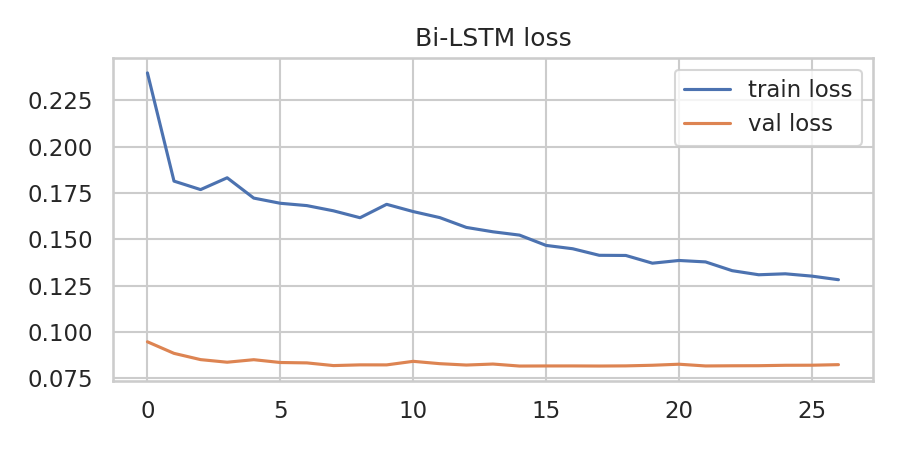

Displaying: plots_15min/BiLSTM_scatter.png


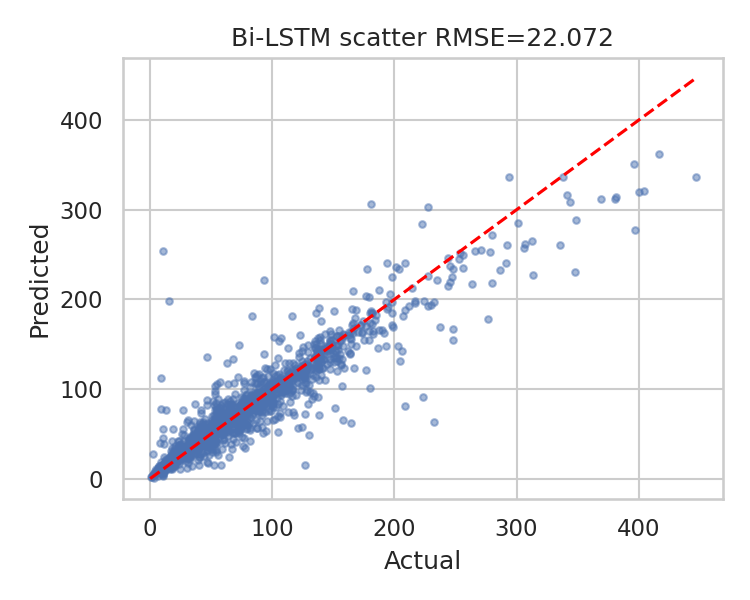

Displaying: plots_15min/BiLSTM_timeseries.png


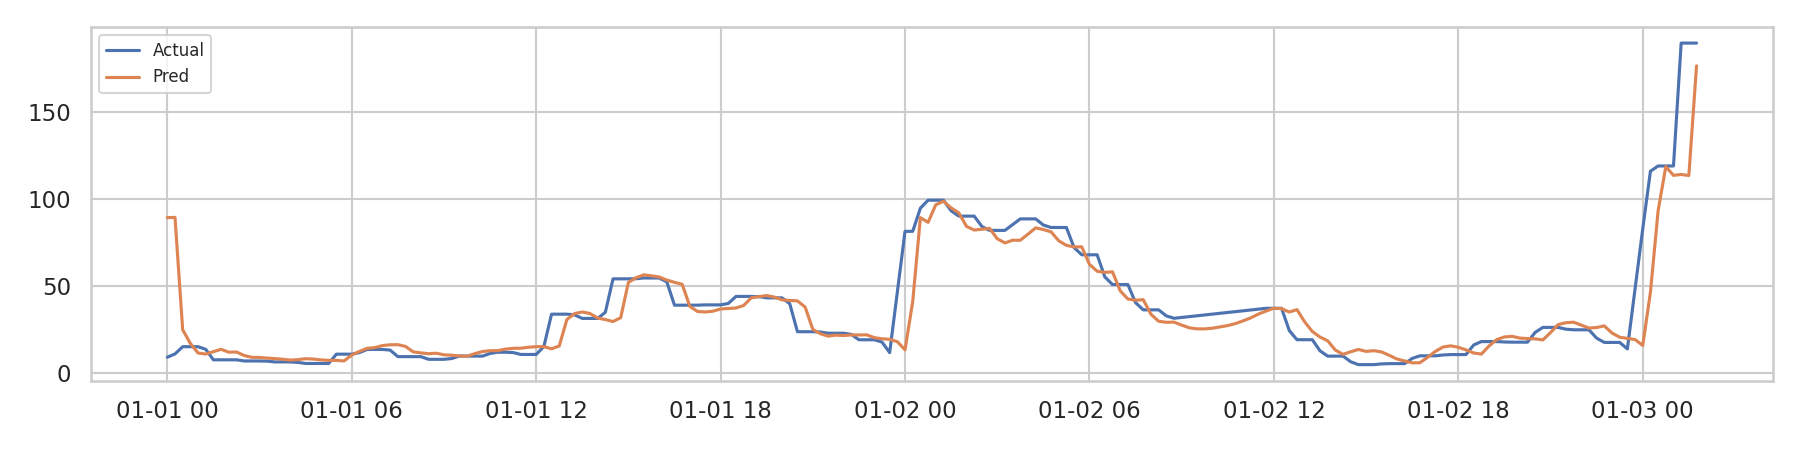

In [ ]:
# Cell: display the saved BiLSTM plots inline
from IPython.display import Image, display
for p in ["plots_15min/BiLSTM_loss.png","plots_15min/BiLSTM_scatter.png","plots_15min/BiLSTM_timeseries.png"]:
    if os.path.exists(p):
        print("Displaying:", p)
        display(Image(p))
    else:
        print("Not found:", p)


In [ ]:
# ===== Cell D: Robust RNN training (copy-paste into Colab) =====
# Purpose: train a simple RNN model using pre-made sequences (if available) or build
# a compact sequence dataset from the cleaned CSV. Includes OOM-safe fallback,
# callbacks, plotting and safe cleanup.

# ---------- Explanation (short):
# - The cell first tries to reuse in-memory variables (X_tr_seq, X_val_seq, X_te_seq, y_tr_seq, y_val_seq, y_te_seq)
# - If not found, it tries to load .npz / .npy files (common filenames from earlier runs).
# - If not found, it performs a lightweight sequence builder from the cleaned CSV (keeps seq_len small by default).
# - Model: small stacked SimpleRNN -> dropout -> Dense. This is much lighter than huge LSTM stacks.
# - If an OOM occurs, the code halves BATCH_SIZE and retries automatically (up to a few times).
# - It saves predictions and three plots: loss curve, scatter actual vs pred, and a short timeseries overlay.
# - Finally, does safe cleanup to free RAM & GPU memory.

# ---------- BEGIN CELL ----------
import os, math, gc, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Paths & filenames (edit if your files are different)
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # fallback CSV (from your earlier cleaning)
OUTPUT_DIR = "predictions_15min"
PLOTS_DIR = "plots_15min"
MODELS_DIR = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Training hyperparams (start conservative to avoid OOM)
SEQ_LEN = 48         # sequence length (48 timesteps => 12 hours at 15-min freq; change if you used 96 before)
BATCH_SIZE = 256     # will auto-reduce on OOM
EPOCHS = 50
UNITS = 128
LEARNING_RATE = 1e-3
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Utility: metrics
def compute_metrics(y_true, y_pred):
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    if mask.sum() == 0:
        return {}
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": float(mse),
        "RMSE": float(math.sqrt(mse)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred))
    }

# Utility: save plots
def save_loss_plot(hist, fname):
    plt.figure(figsize=(6,3.6))
    plt.plot(hist.history.get("loss", []), label="train")
    plt.plot(hist.history.get("val_loss", []), label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss (MSE)")
    plt.title("Training / Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=150); plt.close()

def save_scatter_timeseries(df_merged, model_name, scatter_fname, ts_fname, ts_points=200):
    # scatter
    dfp = df_merged.dropna(subset=["actual","pred"])
    if len(dfp)>0:
        samp = dfp.sample(min(len(dfp),2000), random_state=SEED)
        plt.figure(figsize=(5,4))
        plt.scatter(samp["actual"], samp["pred"], s=10, alpha=0.6)
        mx = max(samp["actual"].max(), samp["pred"].max())
        plt.plot([0,mx],[0,mx],"--", color="red")
        plt.xlabel("Actual"); plt.ylabel("Predicted")
        plt.title(f"{model_name} scatter")
        plt.tight_layout(); plt.savefig(scatter_fname, dpi=150); plt.close()
    # timeseries (first ts_points non-null pairs ordered by timestamp)
    ts = df_merged.dropna(subset=["actual","pred"]).sort_values("timestamp").head(ts_points)
    if len(ts)>0:
        plt.figure(figsize=(9,2.8))
        plt.plot(ts["timestamp"], ts["actual"], label="actual", linewidth=1)
        plt.plot(ts["timestamp"], ts["pred"], label="pred", linewidth=1)
        plt.legend(fontsize=8, loc="upper right")
        plt.title(f"{model_name} actual vs predicted (first {len(ts)})")
        plt.xlabel("timestamp"); plt.ylabel("pm2_5")
        plt.tight_layout(); plt.savefig(ts_fname, dpi=150); plt.close()

# ---------- Step 1: try to obtain sequences (prefer existing arrays) ----------
print("Step 1: look for prebuilt arrays in memory or on disk...")

def try_load_sequences_from_globals():
    names = ["X_tr_seq","X_val_seq","X_te_seq","y_tr_seq","y_val_seq","y_te_seq","timestamps_test"]
    if all(n in globals() for n in names):
        return (globals()["X_tr_seq"], globals()["X_val_seq"], globals()["X_te_seq"],
                globals()["y_tr_seq"], globals()["y_val_seq"], globals()["y_te_seq"],
                globals().get("timestamps_test", None))
    return None

def try_load_sequences_from_disk():
    # common names used in previous cells
    candidates = [
        ("X_tr_seq.npy","X_val_seq.npy","X_te_seq.npy","y_tr_seq.npy","y_val_seq.npy","y_te_seq.npy","timestamps_test.npy"),
        ("seqs_train.npz","seqs_val.npz","seqs_test.npz",None,None,None,None)
    ]
    # npy trio
    if os.path.exists("X_tr_seq.npy") and os.path.exists("y_tr_seq.npy"):
        try:
            X_tr = np.load("X_tr_seq.npy", allow_pickle=True)
            X_val = np.load("X_val_seq.npy", allow_pickle=True) if os.path.exists("X_val_seq.npy") else None
            X_te = np.load("X_te_seq.npy", allow_pickle=True) if os.path.exists("X_te_seq.npy") else None
            y_tr = np.load("y_tr_seq.npy", allow_pickle=True)
            y_val = np.load("y_val_seq.npy", allow_pickle=True) if os.path.exists("y_val_seq.npy") else None
            y_te = np.load("y_te_seq.npy", allow_pickle=True) if os.path.exists("y_te_seq.npy") else None
            ts = np.load("timestamps_test.npy", allow_pickle=True) if os.path.exists("timestamps_test.npy") else None
            return X_tr, X_val, X_te, y_tr, y_val, y_te, ts
        except Exception as e:
            print("npy load failed:", e)
    # single npz
    if os.path.exists("seqs_train.npz") and os.path.exists("seqs_val.npz") and os.path.exists("seqs_test.npz"):
        try:
            tr = np.load("seqs_train.npz")
            val = np.load("seqs_val.npz")
            te = np.load("seqs_test.npz")
            return tr["X"], val["X"], te["X"], tr["y"], val["y"], te["y"], te.get("ts", None)
        except Exception as e:
            print("npz load failed:", e)
    return None

seqs = try_load_sequences_from_globals() or try_load_sequences_from_disk()

# ---------- Step 2: if sequences not found, build compact sequences from cleaned CSV ----------
if seqs is None:
    print("No prebuilt sequences found. Building compact sequences from cleaned CSV (this will be faster & memory conscious).")
    if not os.path.exists(CLEANED_CSV):
        raise FileNotFoundError(f"Cleaned CSV not found: {CLEANED_CSV}. Please run preprocessing cells first.")
    df = pd.read_csv(CLEANED_CSV, parse_dates=["timestamp"], low_memory=False)
    df = df.sort_values("timestamp").reset_index(drop=True)
    # ensure target column present
    target = "pm2_5" if "pm2_5" in df.columns else df.columns[1]
    print("Using target:", target)
    # select a small set of features (lags + meteorology) — adjust if you have different columns
    # create daily/15min sequences: we will use the 'act' column (target) for lag features
    # build rolling features & sequence windows compactly to avoid huge memory
    df2 = df[["timestamp", target]].copy()
    df2 = df2.dropna(subset=[target])   # remove rows where target missing
    df2 = df2.reset_index(drop=True)
    # simple approach: create overlapping sequences (sliding window) directly (keeps memory lower)
    values = df2[target].values.astype(float)
    n = len(values)
    seq_len = SEQ_LEN
    X = []
    y = []
    ts = []
    for i in range(seq_len, n):
        X.append(values[i-seq_len:i].reshape(seq_len,1))  # shape (seq_len, 1)
        y.append(values[i])
        ts.append(df2.loc[i,"timestamp"])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1,1)
    # quick train/val/test split chronologically: 80/10/10
    N = len(X)
    tr_end = int(N*0.8)
    val_end = tr_end + int(N*0.1)
    X_tr, X_val, X_te = X[:tr_end], X[tr_end:val_end], X[val_end:]
    y_tr, y_val, y_te = y[:tr_end], y[tr_end:val_end], y[val_end:]
    timestamps_test = np.array(ts[val_end:], dtype="datetime64[ns]")
    print("Built sequences shapes ->", X_tr.shape, X_val.shape, X_te.shape)
    seqs = (X_tr, X_val, X_te, y_tr, y_val, y_te, timestamps_test)

# unpack
X_tr, X_val, X_te, y_tr, y_val, y_te, timestamps_test = seqs

# if features are single-channel (seq,1) and you want extra features, user can update preprocessing pipeline separately.

print("Final shapes -> X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_test:", X_te.shape)

# ---------- Step 3: build tf.data pipelines ----------
def make_ds(X, y, batch, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(X)), seed=SEED)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# We'll try with BATCH_SIZE and reduce on OOM if needed
attempts = 0
max_attempts = 4
success = False
last_err = None

while attempts < max_attempts and not success:
    try:
        print(f"\nAttempt {attempts+1}: building datasets with BATCH_SIZE={BATCH_SIZE} ...")
        train_ds = make_ds(X_tr, y_tr, BATCH_SIZE, shuffle=True)
        val_ds = make_ds(X_val, y_val, BATCH_SIZE, shuffle=False)
        test_ds = make_ds(X_te, y_te, BATCH_SIZE, shuffle=False)

        # ---------- Step 4: build the RNN model ----------
        tf.keras.backend.clear_session()
        # Mixed precision optional (only enable if you used it earlier and want speed)
        # from tensorflow.keras import mixed_precision
        # mixed_precision.set_global_policy('mixed_float16')

        inp = layers.Input(shape=X_tr.shape[1:], name="input_seq")   # (seq_len, n_features)
        x = layers.SimpleRNN(UNITS, return_sequences=True, activation="tanh")(inp)
        x = layers.Dropout(0.2)(x)
        x = layers.SimpleRNN(UNITS//2, return_sequences=False, activation="tanh")(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation="relu")(x)
        out = layers.Dense(1, name="out")(x)
        model = models.Model(inputs=inp, outputs=out, name="RNN_simple")

        opt = optimizers.Adam(learning_rate=LEARNING_RATE)
        model.compile(optimizer=opt, loss="mse", metrics=["mae"])
        model.summary()

        # ---------- Step 5: callbacks ----------
        ckpt_path = os.path.join(MODELS_DIR, "RNN_simple_best.keras")
        cb = [
            callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=6, verbose=1, min_lr=1e-7),
            callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1)
        ]

        # ---------- Step 6: train ----------
        print("Starting training...")
        hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb, verbose=2)
        success = True

        # ---------- Step 7: load best model and predict ----------
        if os.path.exists(ckpt_path):
            model = tf.keras.models.load_model(ckpt_path)
        preds = model.predict(test_ds, verbose=0)
        # preds shape (n_test,1) ; y_te shape (n_test,1)
        # Build merged DataFrame
        df_out = pd.DataFrame({
            "timestamp": pd.to_datetime(timestamps_test),
            "actual": y_te.flatten(),
            "pred": preds.flatten()
        })
        # Save predictions
        pred_fname = os.path.join(OUTPUT_DIR, "RNN_predictions_ludhiana.csv")
        df_out.to_csv(pred_fname, index=False)
        print("Saved predictions ->", pred_fname)

        # ---------- Step 8: metrics & plots ----------
        metrics = compute_metrics(df_out["actual"].values, df_out["pred"].values)
        print("Test metrics:", metrics)

        # save loss plot
        loss_plot = os.path.join(PLOTS_DIR, "RNN_loss.png")
        save_loss_plot(hist, loss_plot)
        # scatter & timeseries
        scatter_p = os.path.join(PLOTS_DIR, "RNN_scatter.png")
        ts_p = os.path.join(PLOTS_DIR, "RNN_timeseries.png")
        save_scatter_timeseries(df_out, "RNN", scatter_p, ts_p)
        print("Saved plots:", loss_plot, scatter_p, ts_p)

        # Done training: cleanup
        break

    except tf.errors.ResourceExhaustedError as oom:
        last_err = oom
        print("OOM encountered at BATCH_SIZE =", BATCH_SIZE, "-> will reduce BATCH_SIZE and retry.")
        BATCH_SIZE = max(8, BATCH_SIZE // 2)
        attempts += 1
        tf.keras.backend.clear_session()
        gc.collect()
        continue
    except Exception as e:
        last_err = e
        print("Training failed with error:", repr(e))
        # if dataset building stage produced memory error, reduce batch and retry
        if "OOM" in repr(e) or "ResourceExhaustedError" in repr(e):
            BATCH_SIZE = max(8, BATCH_SIZE // 2)
            attempts += 1
            tf.keras.backend.clear_session()
            gc.collect()
            continue
        else:
            raise

if not success:
    print("All attempts failed. Last error:")
    raise last_err

# ---------- Final safe cleanup ----------
print("Final cleanup: clearing TF session and freeing memory.")
tf.keras.backend.clear_session()
# keep essential modules and helper functions; delete large arrays
for v in ["X_tr","X_val","X_te","y_tr","y_val","y_te","X_tr_seq","X_val_seq","X_te_seq","y_tr_seq","y_val_seq","y_te_seq"]:
    if v in globals():
        try:
            del globals()[v]
        except:
            pass
gc.collect()
print("RNN cell finished successfully.")
# ---------- END CELL ----------

Step 1: look for prebuilt arrays in memory or on disk...
No prebuilt sequences found. Building compact sequences from cleaned CSV (this will be faster & memory conscious).
Using target: pm2_5
Built sequences shapes -> (84672, 48, 1) (10584, 48, 1) (10584, 48, 1)
Final shapes -> X_tr: (84672, 48, 1) X_val: (10584, 48, 1) X_test: (10584, 48, 1)

Attempt 1: building datasets with BATCH_SIZE=256 ...


Model: "RNN_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 48, 128)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,105 (121.50 KB)

 Trainable params: 31,105 (121.50 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/50

Epoch 1: val_loss improved from inf to 1121.13220, saving model to models/RNN_simple_best.keras
331/331 - 13s - 39ms/step - loss: 4202.7432 - mae: 29.0005 - val_loss: 1121.1322 - val_mae: 12.2165 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_loss improved from 1121.13220 to 378.32538, saving model to models/RNN_simple_best.keras
331/331 - 3s - 10ms/step - loss: 1622.5927 - mae: 14.3862 - val_loss: 378.3254 - val_mae: 7.7022 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_loss improved from 378.32538 to 257.55450, saving model to models/RNN_simple_best.keras
331/331 - 4s - 12ms/step - loss: 1248.5979 - mae: 13.0076 - val_loss: 257.5545 - val_mae: 8.3139 - learning_rate: 1.0000e-03
Epoch 4/50

Epoch 4: val_loss improved from 257.55450 to 194.96021, saving model to models/RNN_simple_best.keras
331/331 - 3s - 10ms/step - loss: 1051.6648 - mae: 11.7490 - val_loss: 194.9602 - val_mae: 6.3137 - learning_rate: 1.0000e-03
Epoch 5/50

Epoch 5: val_los

📊 RNN Plots:


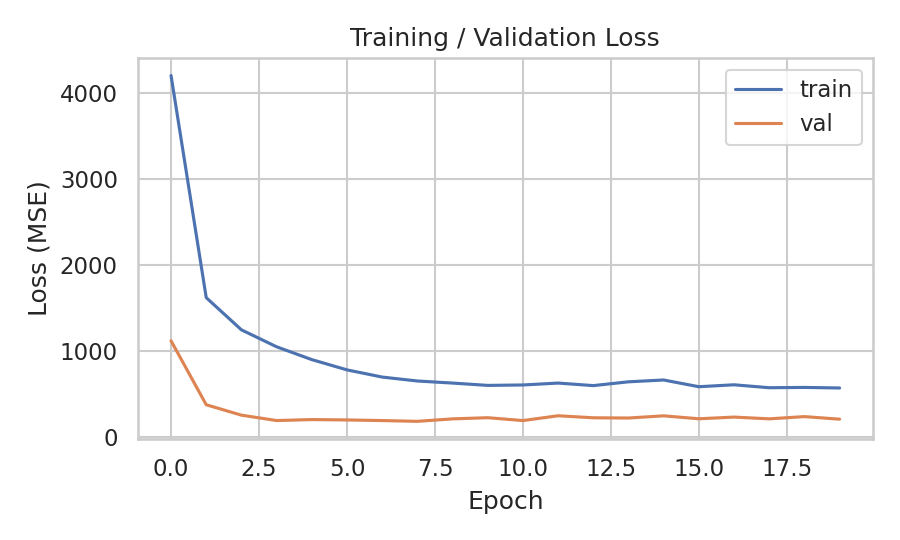

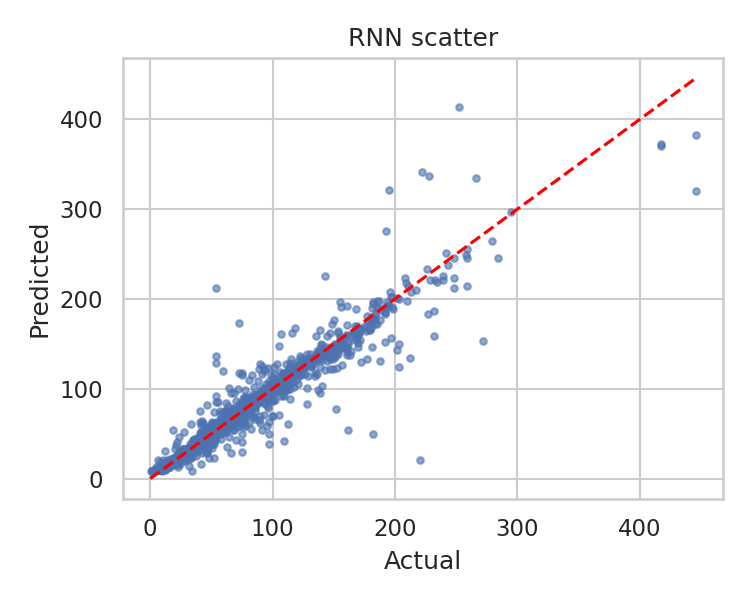

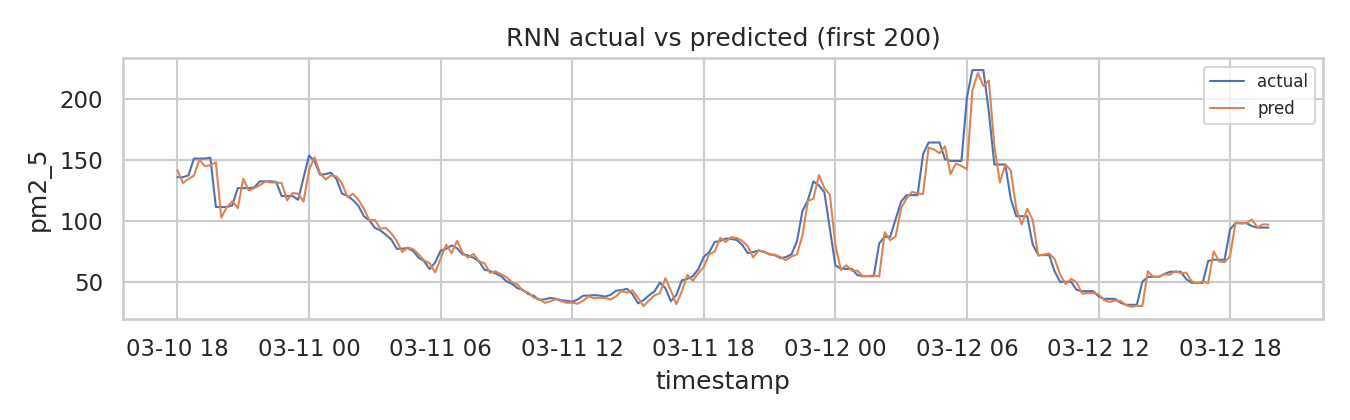

In [ ]:
from IPython.display import Image, display

print("📊 RNN Plots:")
display(Image("plots_15min/RNN_loss.png"))          # Training/validation loss curve
display(Image("plots_15min/RNN_scatter.png"))       # Predicted vs Actual scatter plot
display(Image("plots_15min/RNN_timeseries.png"))    # Predicted vs Actual time series

In [ ]:
# ===== Cell: CNN1D (copy-paste into Colab) =====
import os, math, gc, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Config
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"
OUTPUT_DIR = "predictions_15min"
PLOTS_DIR = "plots_15min"
MODELS_DIR = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEQ_LEN = 48
BATCH_SIZE = 256   # will auto-reduce on OOM
EPOCHS = 50
LEARNING_RATE = 1e-3
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

# helpers
def compute_metrics(y_true, y_pred):
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    if mask.sum()==0:
        return {"MSE":np.nan,"RMSE":np.nan,"MAE":np.nan,"R2":np.nan}
    y_true = y_true[mask]; y_pred = y_pred[mask]
    mse = mean_squared_error(y_true, y_pred)
    return {"MSE":float(mse),"RMSE":float(math.sqrt(mse)),"MAE":float(mean_absolute_error(y_true,y_pred)),"R2":float(r2_score(y_true,y_pred))}

def save_loss_plot(hist, path):
    plt.figure(figsize=(6,3.5))
    plt.plot(hist.history.get("loss",[]), label="train")
    plt.plot(hist.history.get("val_loss",[]), label="val")
    plt.xlabel("epoch"); plt.ylabel("loss (MSE)"); plt.legend()
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.close()

def save_scatter_ts(dfm, name, scatter_path, ts_path, n_ts=200):
    dfp = dfm.dropna(subset=["actual","pred"])
    if len(dfp)>0:
        samp = dfp.sample(min(len(dfp),2000), random_state=SEED)
        plt.figure(figsize=(5,4)); plt.scatter(samp["actual"], samp["pred"], s=10, alpha=0.6)
        mx = max(samp["actual"].max(), samp["pred"].max())
        plt.plot([0,mx],[0,mx],"--", color="red")
        plt.xlabel("Actual"); plt.ylabel("Pred"); plt.title(f"{name} scatter"); plt.tight_layout(); plt.savefig(scatter_path, dpi=150); plt.close()
    ts = dfm.dropna(subset=["actual","pred"]).sort_values("timestamp").head(n_ts)
    if len(ts)>0:
        plt.figure(figsize=(9,2.8))
        plt.plot(ts["timestamp"], ts["actual"], label="actual", linewidth=1)
        plt.plot(ts["timestamp"], ts["pred"], label="pred", linewidth=1)
        plt.legend(fontsize=8); plt.title(f"{name} timeseries (first {len(ts)})")
        plt.xlabel("timestamp"); plt.tight_layout(); plt.savefig(ts_path, dpi=150); plt.close()

# try reuse in-memory arrays if user has them
def try_load_from_globals():
    names = ["X_tr_seq","X_val_seq","X_te_seq","y_tr_seq","y_val_seq","y_te_seq","timestamps_test"]
    if all(n in globals() for n in names):
        return (globals()["X_tr_seq"], globals()["X_val_seq"], globals()["X_te_seq"],
                globals()["y_tr_seq"], globals()["y_val_seq"], globals()["y_te_seq"],
                globals().get("timestamps_test", None))
    return None

def try_load_from_disk():
    try:
        if os.path.exists("X_tr_seq.npy") and os.path.exists("y_tr_seq.npy"):
            X_tr = np.load("X_tr_seq.npy", allow_pickle=True); X_val = np.load("X_val_seq.npy", allow_pickle=True) if os.path.exists("X_val_seq.npy") else None
            X_te = np.load("X_te_seq.npy", allow_pickle=True) if os.path.exists("X_te_seq.npy") else None
            y_tr = np.load("y_tr_seq.npy", allow_pickle=True); y_val = np.load("y_val_seq.npy", allow_pickle=True) if os.path.exists("y_val_seq.npy") else None
            y_te = np.load("y_te_seq.npy", allow_pickle=True) if os.path.exists("y_te_seq.npy") else None
            ts = np.load("timestamps_test.npy", allow_pickle=True) if os.path.exists("timestamps_test.npy") else None
            return X_tr, X_val, X_te, y_tr, y_val, y_te, ts
    except Exception as e:
        print("Disk load failed:", e)
    return None

seqs = try_load_from_globals() or try_load_from_disk()

# build compact sequences if not available
if seqs is None:
    print("No prebuilt sequences — building compact sequences from CSV")
    if not os.path.exists(CLEANED_CSV):
        raise FileNotFoundError(f"Cleaned CSV not found: {CLEANED_CSV}")
    df = pd.read_csv(CLEANED_CSV, parse_dates=["timestamp"], low_memory=False)
    df = df.sort_values("timestamp").reset_index(drop=True)
    target = "pm2_5" if "pm2_5" in df.columns else df.columns[1]
    vals = df[target].astype(np.float32).values
    # drop rows with NaNs in target to avoid sequences with NaN ends
    mask = ~np.isnan(vals)
    if mask.sum() < len(vals):
        df = df[mask].reset_index(drop=True)
        vals = df[target].astype(np.float32).values
    n = len(vals)
    seq_len = SEQ_LEN
    X=[]; y=[]; ts=[]
    for i in range(seq_len, n):
        X.append(vals[i-seq_len:i].reshape(seq_len,1))
        y.append(vals[i])
        ts.append(df.loc[i,"timestamp"])
    X = np.asarray(X, dtype=np.float32); y = np.asarray(y, dtype=np.float32).reshape(-1,1)
    N = len(X)
    tr_end = int(N*0.8); val_end = tr_end + int(N*0.1)
    X_tr, X_val, X_te = X[:tr_end], X[tr_end:val_end], X[val_end:]
    y_tr, y_val, y_te = y[:tr_end], y[tr_end:val_end], y[val_end:]
    timestamps_test = np.array(ts[val_end:], dtype="datetime64[ns]")
    seqs = (X_tr, X_val, X_te, y_tr, y_val, y_te, timestamps_test)
    print("Built sequences shapes ->", X_tr.shape, X_val.shape, X_te.shape)

X_tr, X_val, X_te, y_tr, y_val, y_te, timestamps_test = seqs
print("Final shapes -> X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_test:", X_te.shape)

# dataset helper
def make_ds(X,y,batch,shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(X)), seed=SEED)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# train with OOM resilience
attempts=0; max_attempts=4; success=False; last_err=None
while attempts < max_attempts and not success:
    try:
        print(f"Attempt {attempts+1}: BATCH_SIZE={BATCH_SIZE}")
        train_ds = make_ds(X_tr, y_tr, BATCH_SIZE, shuffle=True)
        val_ds = make_ds(X_val, y_val, BATCH_SIZE, shuffle=False)
        test_ds = make_ds(X_te, y_te, BATCH_SIZE, shuffle=False)

        tf.keras.backend.clear_session()
        inp = layers.Input(shape=X_tr.shape[1:], name="input_seq")  # (SEQ_LEN, features)
        x = inp
        # Conv stack: 3 conv layers with pooling
        x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Dense(64, activation="relu")(x)
        out = layers.Dense(1, name="out")(x)
        model = models.Model(inp, out, name="CNN1D_model")
        opt = optimizers.Adam(learning_rate=LEARNING_RATE)
        model.compile(optimizer=opt, loss="mse", metrics=["mae"])
        model.summary()

        ckpt = os.path.join(MODELS_DIR, "CNN1D_best.keras")
        cbs = [
            callbacks.ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=6, verbose=1, min_lr=1e-7),
            callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1)
        ]

        hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cbs, verbose=2)
        success=True

        # load best model if saved and predict
        if os.path.exists(ckpt):
            model = tf.keras.models.load_model(ckpt)
        preds = model.predict(test_ds, verbose=0)
        df_out = pd.DataFrame({"timestamp": pd.to_datetime(timestamps_test), "actual": y_te.flatten(), "pred": preds.flatten()})
        out_csv = os.path.join(OUTPUT_DIR, "CNN1D_predictions_ludhiana.csv")
        df_out.to_csv(out_csv, index=False)
        print("Saved predictions:", out_csv)

        metrics = compute_metrics(df_out["actual"].values, df_out["pred"].values)
        print("CNN1D Test metrics:", metrics)

        loss_png = os.path.join(PLOTS_DIR, "CNN1D_loss.png")
        sc_png = os.path.join(PLOTS_DIR, "CNN1D_scatter.png")
        ts_png = os.path.join(PLOTS_DIR, "CNN1D_timeseries.png")
        save_loss_plot(hist, loss_png)
        save_scatter_ts(df_out, "CNN1D", sc_png, ts_png)
        print("Saved plots:", loss_png, sc_png, ts_png)

        break

    except tf.errors.ResourceExhaustedError as oom:
        last_err = oom
        print("OOM encountered -> reducing batch and retrying.")
        BATCH_SIZE = max(8, BATCH_SIZE//2)
        attempts += 1
        tf.keras.backend.clear_session(); gc.collect()
        continue
    except Exception as e:
        last_err = e
        print("Training failed:", repr(e))
        if "OOM" in repr(e) or "ResourceExhaustedError" in repr(e):
            BATCH_SIZE = max(8, BATCH_SIZE//2)
            attempts += 1
            tf.keras.backend.clear_session(); gc.collect()
            continue
        else:
            raise

if not success:
    print("All attempts failed. Last error:")
    raise last_err

# final cleanup
tf.keras.backend.clear_session()
for v in ["X_tr","X_val","X_te","y_tr","y_val","y_te","X_tr_seq","X_val_seq","X_te_seq","y_tr_seq","y_val_seq","y_te_seq"]:
    if v in globals():
        try: del globals()[v]
        except: pass
gc.collect()
print("CNN1D cell finished successfully.")

No prebuilt sequences — building compact sequences from CSV
Built sequences shapes -> (84672, 48, 1) (10584, 48, 1) (10584, 48, 1)
Final shapes -> X_tr: (84672, 48, 1) X_val: (10584, 48, 1) X_test: (10584, 48, 1)
Attempt 1: BATCH_SIZE=256


Model: "CNN1D_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 12, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,689 (323.00 KB)

 Trainable params: 82,689 (323.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50

Epoch 1: val_loss improved from inf to 234.19582, saving model to models/CNN1D_best.keras
331/331 - 8s - 25ms/step - loss: 1313.7339 - mae: 16.4120 - val_loss: 234.1958 - val_mae: 7.2268 - learning_rate: 1.0000e-03
Epoch 2/50

Epoch 2: val_loss improved from 234.19582 to 201.44318, saving model to models/CNN1D_best.keras
331/331 - 2s - 6ms/step - loss: 516.1391 - mae: 8.9759 - val_loss: 201.4432 - val_mae: 6.2565 - learning_rate: 1.0000e-03
Epoch 3/50

Epoch 3: val_loss improved from 201.44318 to 188.16382, saving model to models/CNN1D_best.keras
331/331 - 2s - 6ms/step - loss: 487.2632 - mae: 8.7106 - val_loss: 188.1638 - val_mae: 5.9445 - learning_rate: 1.0000e-03
Epoch 4/50

Epoch 4: val_loss did not improve from 188.16382
331/331 - 1s - 4ms/step - loss: 481.8857 - mae: 8.6184 - val_loss: 188.5720 - val_mae: 6.0356 - learning_rate: 1.0000e-03
Epoch 5/50

Epoch 5: val_loss did not improve from 188.16382
331/331 - 1s - 4ms/step - loss: 463.7053 - mae: 8.2274 - val_loss: 18

📊 CNN1D Plots:


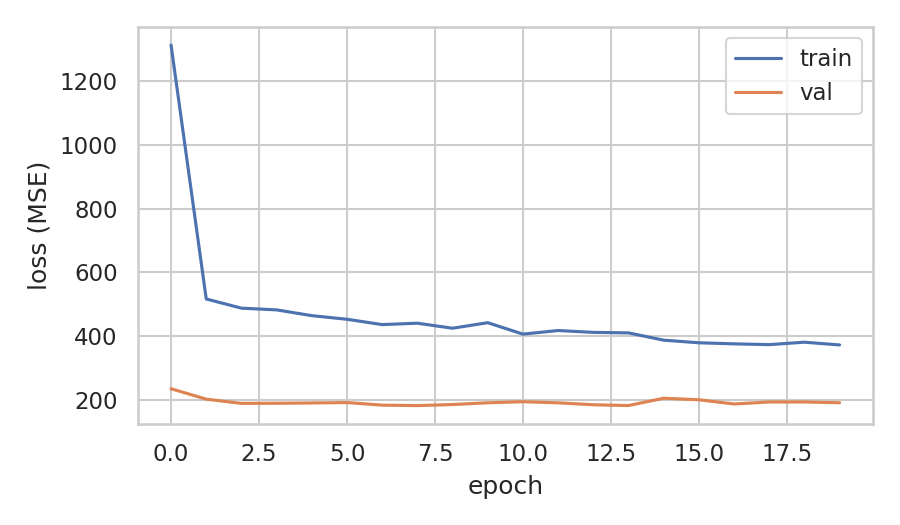

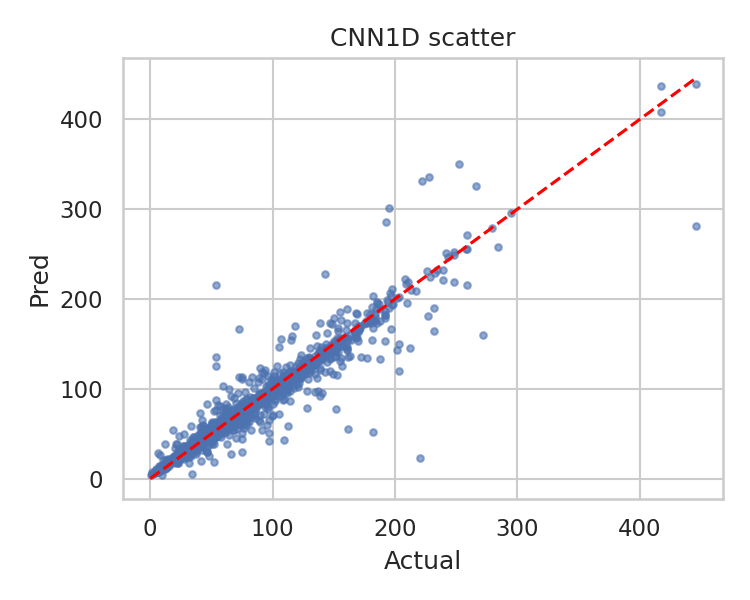

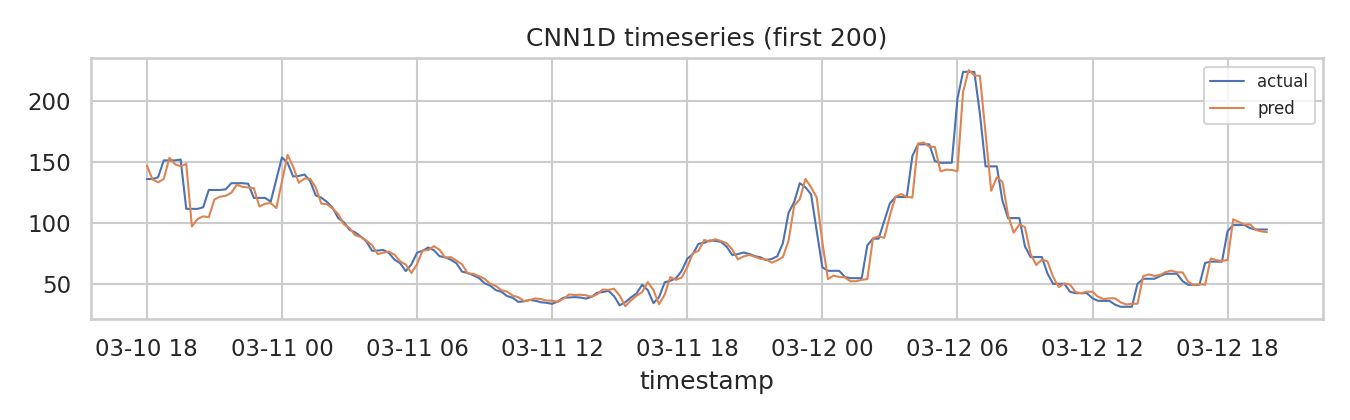

In [ ]:
from IPython.display import Image, display

print("📊 CNN1D Plots:")
display(Image("plots_15min/CNN1D_loss.png"))        # Training/validation loss curve
display(Image("plots_15min/CNN1D_scatter.png"))     # Predicted vs Actual scatter plot
display(Image("plots_15min/CNN1D_timeseries.png"))  # Predicted vs Actual time series


In [ ]:
# -----------------------
# Cell: LightGBM (robust single-cell)
# Paste & run on Colab
# -----------------------
import os, gc, math, warnings, time
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# --- Config (edit if needed) ---
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # must exist
TS_COL = "timestamp"
TARGET = "pm2_5"
FEATURES = ['lag_1','lag_2','lag_3','roll_3','roll_7','sin_doy','cos_doy','rh','wind_speed']
OUT_DIR = "predictions_15min"
PLOT_DIR = "plots_15min"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# --- helpers ---
def rmse(a,b): return math.sqrt(mean_squared_error(a,b))
def metrics_from(y_true,y_pred):
    mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
    if mask.sum()==0:
        return {"MSE":np.nan,"RMSE":np.nan,"MAE":np.nan,"R2":np.nan}
    y_true = np.array(y_true)[mask]; y_pred = np.array(y_pred)[mask]
    mse = mean_squared_error(y_true,y_pred)
    return {"MSE":float(mse),"RMSE":float(math.sqrt(mse)),"MAE":float(mean_absolute_error(y_true,y_pred)),"R2":float(r2_score(y_true,y_pred))}

def plot_scatter_timeseries(df, model_name, ts_col=TS_COL, out_dir=PLOT_DIR):
    dfp = df.dropna(subset=['actual','pred'])
    if len(dfp)==0:
        print("No paired rows to plot for", model_name); return None, None
    samp = dfp.sample(min(len(dfp),2000), random_state=42)
    scatter_path = os.path.join(out_dir, f"{model_name}_scatter.png")
    plt.figure(figsize=(5,4))
    plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.6)
    mx = max(samp['actual'].max(), samp['pred'].max())
    plt.plot([0,mx],[0,mx], '--', color='red')
    plt.xlabel("Actual PM2.5"); plt.ylabel("Predicted PM2.5")
    plt.title(f"{model_name} scatter")
    plt.tight_layout(); plt.savefig(scatter_path, dpi=150); plt.close()

    ts_path = os.path.join(out_dir, f"{model_name}_timeseries.png")
    ts = dfp.sort_values(ts_col).head(200)
    plt.figure(figsize=(9,3))
    plt.plot(ts[ts_col], ts['actual'], label='Actual', linewidth=1)
    plt.plot(ts[ts_col], ts['pred'], label='Predicted', linewidth=1)
    plt.legend(fontsize=8, loc='upper right')
    plt.xlabel("Timestamp"); plt.ylabel("PM2.5")
    plt.title(f"{model_name} actual vs predicted (first {len(ts)})")
    plt.tight_layout(); plt.savefig(ts_path, dpi=150); plt.close()
    return scatter_path, ts_path

# --- Load CSV robustly ---
assert os.path.exists(CLEANED_CSV), f"CSV not found: {CLEANED_CSV}"
try:
    df = pd.read_csv(CLEANED_CSV, parse_dates=[TS_COL])
except Exception:
    df = pd.read_csv(CLEANED_CSV, parse_dates=[TS_COL], engine='python')
df = df.sort_values(TS_COL).reset_index(drop=True)
print("Loaded shape:", df.shape, "Time span:", df[TS_COL].min(), "→", df[TS_COL].max())

# --- Build missing features if needed (safe) ---
missing = [c for c in FEATURES if c not in df.columns]
if missing:
    print("Missing feature columns detected:", missing, "→ building basic features")
    # lags and rolling on TARGET (assume regular 15-min frequency; if irregular this still works)
    for lag in [1,2,3]:
        col = f"lag_{lag}"
        if col not in df.columns:
            df[col] = df[TARGET].shift(lag)
    if 'roll_3' not in df.columns:
        df['roll_3'] = df[TARGET].rolling(window=3, min_periods=1).mean().shift(1)
    if 'roll_7' not in df.columns:
        df['roll_7'] = df[TARGET].rolling(window=7, min_periods=1).mean().shift(1)
    if 'sin_doy' not in df.columns or 'cos_doy' not in df.columns:
        doy = df[TS_COL].dt.dayofyear
        df['sin_doy'] = np.sin(2*np.pi*doy/365.25)
        df['cos_doy'] = np.cos(2*np.pi*doy/365.25)
    for m in ['rh','wind_speed']:
        if m not in df.columns:
            df[m] = np.nan

# --- Prepare model DataFrame & time-split ---
df_model = df[[TS_COL, TARGET] + FEATURES].copy()
# If 2024 exists, use 2024 as test like before
if df_model[TS_COL].dt.year.max() >= 2024:
    test_start = pd.Timestamp("2024-01-01")
    train_val = df_model[df_model[TS_COL] < test_start].copy()
    test_df = df_model[df_model[TS_COL] >= test_start].copy()
else:
    cut = int(len(df_model)*0.8)
    train_val = df_model.iloc[:cut].copy()
    test_df = df_model.iloc[cut:].copy()

val_cut = int(len(train_val)*0.8)
train_df = train_val.iloc[:val_cut].copy()
val_df = train_val.iloc[val_cut:].copy()

print("Rows -> train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

# Drop NA rows for training (features + target)
train_df = train_df.dropna(subset=FEATURES+[TARGET])
val_df = val_df.dropna(subset=FEATURES+[TARGET])
# For test keep rows that have feature values (actual may be present)
test_df = test_df.dropna(subset=FEATURES)

X_tr = train_df[FEATURES].values; y_tr = train_df[TARGET].values
X_val = val_df[FEATURES].values; y_val = val_df[TARGET].values
X_test = test_df[FEATURES].values; ts_test = test_df[TS_COL].values

print("Using features:", FEATURES)
print("Shapes -> X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# --- scale features (keeps original scale for metrics) ---
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_val_s = sc.transform(X_val)
X_test_s = sc.transform(X_test)

# --- Train multiple LGBM models with different n_estimators and pick best by val RMSE ---
n_estimators_try = [100, 200, 400]
best = {"rmse": 1e9, "n": None, "model": None, "metrics": None}
val_scores = []
start_all = time.time()
for n in n_estimators_try:
    print(f"\nTraining LGBM n_estimators={n} ...")
    clf = LGBMRegressor(n_estimators=n, learning_rate=0.05, num_leaves=31,
                        n_jobs=-1, random_state=42)
    # fit without using early_stopping_rounds to avoid API mismatch
    clf.fit(X_tr_s, y_tr)
    # predict on val
    yvalp = clf.predict(X_val_s)
    val_rmse = rmse(y_val, yvalp)
    val_scores.append((n, val_rmse))
    print(f"val RMSE (n={n}) = {val_rmse:.4f}")
    if val_rmse < best["rmse"]:
        best["rmse"] = val_rmse
        best["n"] = n
        best["model"] = clf
        best["metrics"] = {"val_rmse":val_rmse}
end_all = time.time()
print("\nTried n_estimators:", val_scores, f" — selection time {end_all-start_all:.1f}s")
print("Selected best n_estimators =", best["n"])

# --- Use best model to predict test set ---
model = best["model"]
# ensure we have booster for predict flexibility; fallback if not
try:
    y_test_pred = model.predict(X_test_s)
except Exception:
    y_test_pred = model.predict(X_test)

# assemble test dataframe (timestamp, pred, actual if present)
test_out = pd.DataFrame({TS_COL: ts_test})
test_out['pred'] = y_test_pred
# merge actuals when available
actuals = df_model[[TS_COL, TARGET]].rename(columns={TARGET:'actual'})
test_out = test_out.merge(actuals, on=TS_COL, how='left')

# compute metrics (where actual exists)
metrics = metrics_from(test_out['actual'], test_out['pred'])
print("\nLightGBM Test metrics:", metrics)

# save predictions
pred_csv = os.path.join(OUT_DIR, "lightgbm_predictions_ludhiana.csv")
test_out.to_csv(pred_csv, index=False)
print("Saved predictions ->", pred_csv)

# --- Plot validation-vs-n_estimators curve (simple) ---
plt.figure(figsize=(6,3))
ns = [v[0] for v in val_scores]; rmses = [v[1] for v in val_scores]
plt.plot(ns, rmses, marker='o'); plt.xlabel("n_estimators"); plt.ylabel("Val RMSE")
plt.title("LightGBM val RMSE vs n_estimators"); plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"LightGBM_valRMSE_vs_n_estimators.png"), dpi=150); plt.close()
print("Saved val-RMSE plot.")

# --- scatter & timeseries plots ---
sc_path, ts_path = plot_scatter_timeseries(test_out, "LightGBM")
print("Saved scatter & timeseries ->", sc_path, ts_path)

# --- Save metrics summary ---
pd.DataFrame([metrics], index=["LightGBM"]).to_csv(os.path.join(PLOT_DIR,"LightGBM_metrics_summary.csv"))

# --- cleanup ---
del X_tr, X_val, X_test, X_tr_s, X_val_s, X_test_s, train_df, val_df, test_df, df_model
try:
    del model
    del clf
except:
    pass
gc.collect()
import tensorflow as tf
try:
    tf.keras.backend.clear_session()
except Exception:
    pass

print("LightGBM cell finished. Outputs in:", OUT_DIR, PLOT_DIR)


Loaded shape: (105888, 57) Time span: 2017-01-06 00:00:00 → 2024-12-12 23:45:00
Missing feature columns detected: ['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_7', 'sin_doy', 'cos_doy'] → building basic features
Rows -> train: 73651 val: 18413 test: 13824
Using features: ['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_7', 'sin_doy', 'cos_doy', 'rh', 'wind_speed']
Shapes -> X_tr: (73648, 9) X_val: (18413, 9) X_test: (13824, 9)

Training LGBM n_estimators=100 ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2095
[LightGBM] [Info] Number of data points in the train set: 73648, number of used features: 9
[LightGBM] [Info] Start training from score 67.146712
val RMSE (n=100) = 14.0104

Training LGBM n_estimators=200 ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019269 seconds.
You can set `force_col_wise=tru

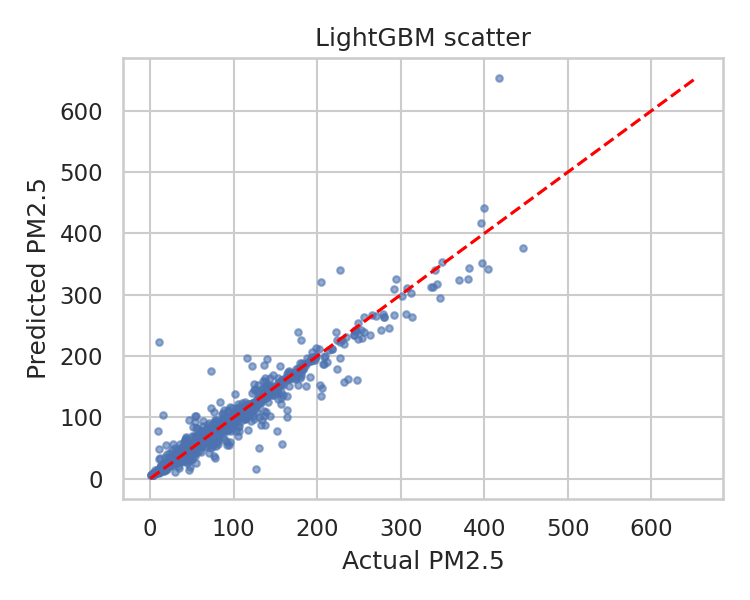

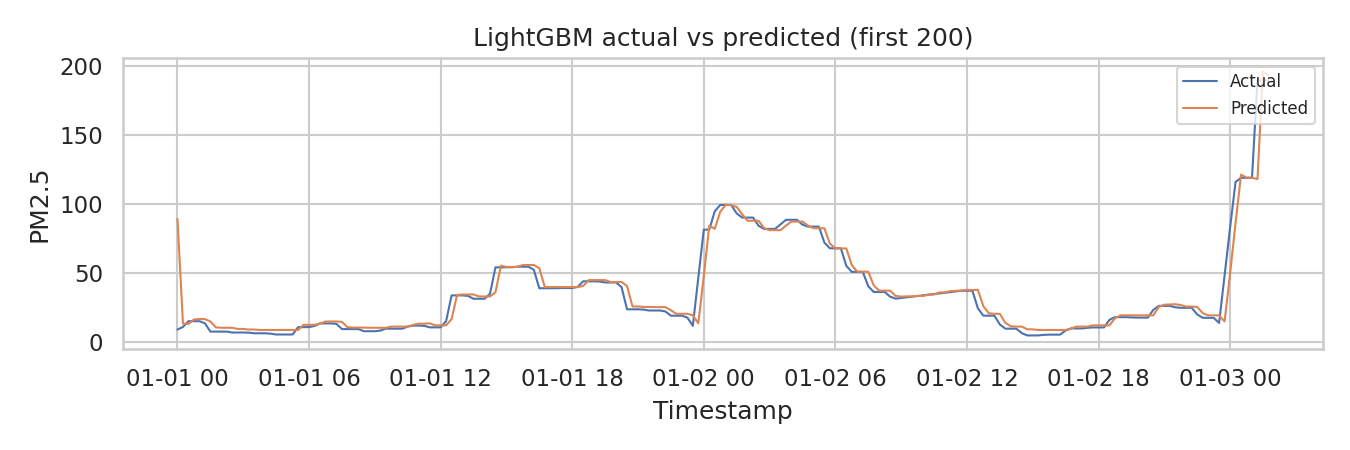

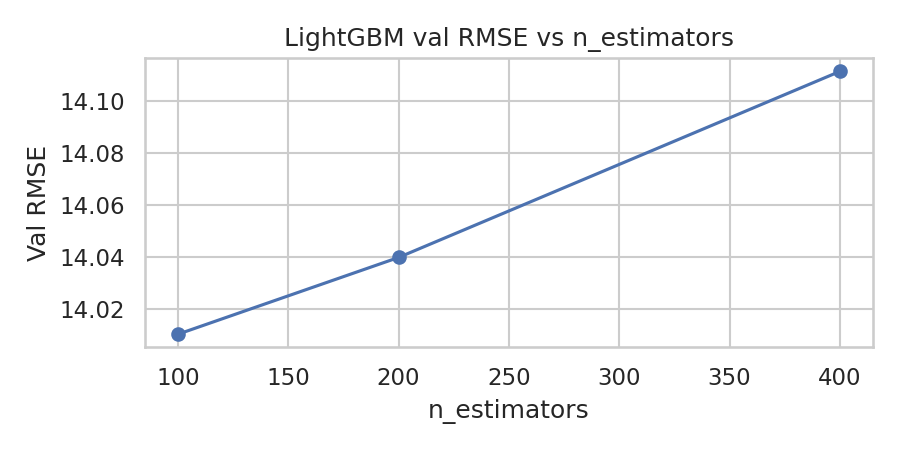

In [ ]:
from IPython.display import Image, display
display(Image("plots_15min/LightGBM_scatter.png"))
display(Image("plots_15min/LightGBM_timeseries.png"))
display(Image("plots_15min/LightGBM_valRMSE_vs_n_estimators.png"))


In [ ]:
# Cell: N-BEATS (single Colab cell) — copy & run
# Requirements: tensorflow (>=2.8), sklearn, matplotlib, pandas, numpy
import os, gc, math
from glob import glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# ---------- USER CONFIG ----------
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # change if your file name differs
TARGET_COL = "pm2_5"          # change if target column name differs
SEQ_LEN = 48                  # lookback length (48 x 15min = 12 hours); adjust if you want
BATCH_SIZE = 256
EPOCHS = 50
MODEL_DIR = "models_nbeats"
PLOTS_DIR = "plots_nbeats"
PRED_DIR = "predictions_nbeats"
START_TEST = pd.Timestamp("2024-01-01")  # everything >= this is used as test set timestamps
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

print("Loading CSV:", CLEANED_CSV)
df = pd.read_csv(CLEANED_CSV, parse_dates=['timestamp'], low_memory=False)
df = df.sort_values('timestamp').reset_index(drop=True)
assert TARGET_COL in df.columns, f"Target column {TARGET_COL} not found"
print("Time span:", df['timestamp'].min(), "->", df['timestamp'].max())
print("Rows:", len(df))

# ---------- Build univariate sliding windows (target-only) ----------
y_full = df[[ 'timestamp', TARGET_COL ]].rename(columns={TARGET_COL: "actual"})
# ensure regular frequency (we don't force-resample — we assume your CSV is regular)
vals = y_full['actual'].values.astype(np.float32)

def make_sequences(vals, timestamps, seq_len):
    """
    Build X (seq_len values) -> y (next-step) sequences aligned to timestamps.
    Returns arrays and aligned timestamps for the y (target timestamp).
    """
    n = len(vals)
    Xs = []
    ys = []
    times = []
    for end_idx in range(seq_len, n):
        start_idx = end_idx - seq_len
        Xs.append(vals[start_idx:end_idx].reshape(seq_len, 1))
        ys.append(vals[end_idx])
        times.append(timestamps[end_idx])
    return np.array(Xs), np.array(ys), np.array(times)

X_all, y_all, times_all = make_sequences(vals, y_full['timestamp'].values, SEQ_LEN)
print("Total sequences built:", X_all.shape, y_all.shape)

# ---------- Train/Val/Test split by time ----------
mask_test = times_all >= np.datetime64(START_TEST)
X_test, y_test, times_test = X_all[mask_test], y_all[mask_test], times_all[mask_test]
X_trainval, y_trainval, times_trainval = X_all[~mask_test], y_all[~mask_test], times_all[~mask_test]

# time-based val split (last 20% of trainval as val)
n_tv = len(X_trainval)
val_start = int(n_tv * 0.8)
X_tr = X_trainval[:val_start]; y_tr = y_trainval[:val_start]
X_val = X_trainval[val_start:]; y_val = y_trainval[val_start:]

print("Shapes -> X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# ---------- Scaling: standardize based on train target values (univariate) ----------
scaler_x = StandardScaler()
# For N-BEATS we'll flatten time axis to fit scaler but keep shape after
X_tr_flat = X_tr.reshape(-1, 1)
scaler_x.fit(X_tr_flat)
def scale_X(X):
    s = X.reshape(-1,1)
    s = scaler_x.transform(s)
    return s.reshape(X.shape)
X_tr_s = scale_X(X_tr)
X_val_s = scale_X(X_val)
X_test_s = scale_X(X_test)

scaler_y = StandardScaler()
y_tr_s = scaler_y.fit_transform(y_tr.reshape(-1,1)).ravel()
y_val_s = scaler_y.transform(y_val.reshape(-1,1)).ravel()
y_test_s = scaler_y.transform(y_test.reshape(-1,1)).ravel()

# ---------- N-BEATS model builder (basic block, many papers' simple variant) ----------
def nbeats_block(input_tensor, units, thetas_dim, nb_layers=4, layer_width=256, name="block"):
    """
    A simple N-BEATS block (fully-connected stacks) that returns backcast + forecast.
    We'll implement a simplified variant: final forecast is a dense to horizon=1.
    """
    x = layers.Flatten()(input_tensor)
    for i in range(nb_layers):
        x = layers.Dense(layer_width, activation="relu")(x)
    # forecast head (since horizon=1)
    forecast = layers.Dense(thetas_dim, activation=None, name=name + "_forecast")(x)
    return forecast

def build_nbeats(seq_len, nb_blocks=3, nb_layers=4, layer_width=256):
    inp = layers.Input(shape=(seq_len,1), name="inp")
    # stack blocks and sum forecasts
    forecasts = []
    for b in range(nb_blocks):
        f = nbeats_block(inp, units=None, thetas_dim=1, nb_layers=nb_layers, layer_width=layer_width, name=f"b{b}")
        forecasts.append(f)
    if len(forecasts) > 1:
        out = layers.Add()(forecasts)
    else:
        out = forecasts[0]
    out = layers.Reshape((1,))(out)
    model = models.Model(inp, out, name="NBEATS_simple")
    return model

# Build model
tf.keras.backend.clear_session()
model = build_nbeats(SEQ_LEN, nb_blocks=3, nb_layers=3, layer_width=256)
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.summary()

# ---------- Callbacks ----------
cb_list = [
    callbacks.ModelCheckpoint(os.path.join(MODEL_DIR,"nbeats_best.keras"), save_best_only=True, monitor="val_loss"),
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-6, verbose=1)
]

# ---------- Training ----------
history = model.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_val_s, y_val_s),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=2
)

# Save final model (best weights are restored by callbacks)
model.save(os.path.join(MODEL_DIR,"nbeats_final.keras"))

# ---------- Plot loss curve ----------
plt.figure(figsize=(6,3.5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("N-BEATS loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
loss_path = os.path.join(PLOTS_DIR, "NBEATS_loss.png")
plt.savefig(loss_path, dpi=150)
plt.close()
print("Saved loss plot ->", loss_path)

# ---------- Predict on test set (inverse scale to original units) ----------
y_pred_s = model.predict(X_test_s, batch_size=1024).ravel()
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()

# Save predictions CSV with timestamp, actual, pred
out_df = pd.DataFrame({"timestamp": pd.to_datetime(times_test), "actual": y_test, "pred": y_pred})
pred_path = os.path.join(PRED_DIR, "NBEATS_predictions_2024_ludhiana.csv")
out_df.to_csv(pred_path, index=False)
print("Saved predictions ->", pred_path)

# ---------- Metrics ----------
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return {"MSE":mse, "RMSE":rmse, "MAE":mae, "R2":r2}

metrics = compute_metrics(out_df['actual'], out_df['pred'])
print("N-BEATS Test metrics:", metrics)

# ---------- Scatter plot (actual vs pred) ----------
plt.figure(figsize=(5,4))
samp = out_df.dropna()
if len(samp) > 2000:
    samp = samp.sample(2000, random_state=42)
plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.6)
mx = max(samp['actual'].max(), samp['pred'].max())
plt.plot([0,mx],[0,mx], '--', color='red')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title(f"N-BEATS scatter — R2={metrics['R2']:.3f}")
plt.tight_layout()
scatter_path = os.path.join(PLOTS_DIR, "NBEATS_scatter.png")
plt.savefig(scatter_path, dpi=150)
plt.close()
print("Saved scatter ->", scatter_path)

# ---------- Timeseries overlay (first N points) ----------
ts = out_df.dropna().sort_values('timestamp').head(200)
plt.figure(figsize=(8,3))
plt.plot(ts['timestamp'], ts['actual'], label='Actual', linewidth=1)
plt.plot(ts['timestamp'], ts['pred'], label='Predicted', linewidth=1)
plt.legend(fontsize=8, loc='upper right')
plt.title("N-BEATS Actual vs Predicted (first sample)")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5")
plt.tight_layout()
ts_path = os.path.join(PLOTS_DIR, "NBEATS_timeseries.png")
plt.savefig(ts_path, dpi=150)
plt.close()
print("Saved timeseries ->", ts_path)

# ---------- Final cleanup to free RAM ----------
del X_all, y_all, X_tr, X_val, X_test, X_tr_s, X_val_s, X_test_s, X_trainval, y_trainval
del X_tr_flat, y_tr_s, y_val_s, y_test_s
tf.keras.backend.clear_session()
import gc
gc.collect()
print("Done. Plots & predictions saved. Memory cleaned.")


Loading CSV: /content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv
Time span: 2017-01-06 00:00:00 -> 2024-12-12 23:45:00
Rows: 105888
Total sequences built: (105840, 48, 1) (105840,)
Shapes -> X_tr: (73612, 48, 1) X_val: (18404, 48, 1) X_test: (13824, 48, 1)


Model: "NBEATS_simple"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inp (InputLayer)    │ (None, 48, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 48)        │          0 │ inp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 48)        │          0 │ inp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 48)        │          0 │ inp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     12,544 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     12,544 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     12,544 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     65,792 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     65,792 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b0_forecast (Dense) │ (None, 1)         │        257 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_forecast (Dense) │ (None, 1)         │        257 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_forecast (Dense) │ (None, 1)         │        257 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ b0_forecast[0][0… │
│                     │                   │            │ b1_forecast[0][0… │
│                     │                   │            │ b2_forecast[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1)         │          0 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 433,155 (1.65 MB)

 Trainable params: 433,155 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
288/288 - 9s - 32ms/step - loss: 0.1963 - mae: 0.2000 - val_loss: 0.0717 - val_mae: 0.1651 - learning_rate: 1.0000e-03
Epoch 2/50
288/288 - 1s - 4ms/step - loss: 0.1171 - mae: 0.1403 - val_loss: 0.0600 - val_mae: 0.1360 - learning_rate: 1.0000e-03
Epoch 3/50
288/288 - 1s - 4ms/step - loss: 0.1014 - mae: 0.1279 - val_loss: 0.0512 - val_mae: 0.1168 - learning_rate: 1.0000e-03
Epoch 4/50
288/288 - 1s - 4ms/step - loss: 0.0924 - mae: 0.1221 - val_loss: 0.0502 - val_mae: 0.1153 - learning_rate: 1.0000e-03
Epoch 5/50
288/288 - 1s - 4ms/step - loss: 0.0850 - mae: 0.1162 - val_loss: 0.0489 - val_mae: 0.1143 - learning_rate: 1.0000e-03
Epoch 6/50
288/288 - 1s - 4ms/step - loss: 0.0818 - mae: 0.1158 - val_loss: 0.0502 - val_mae: 0.1179 - learning_rate: 1.0000e-03
Epoch 7/50
288/288 - 1s - 4ms/step - loss: 0.0798 - mae: 0.1147 - val_loss: 0.0519 - val_mae: 0.1221 - learning_rate: 1.0000e-03
Epoch 8/50
288/288 - 1s - 5ms/step - loss: 0.0791 - mae: 0.1116 - val_loss: 0.0492 - val_mae: 0.

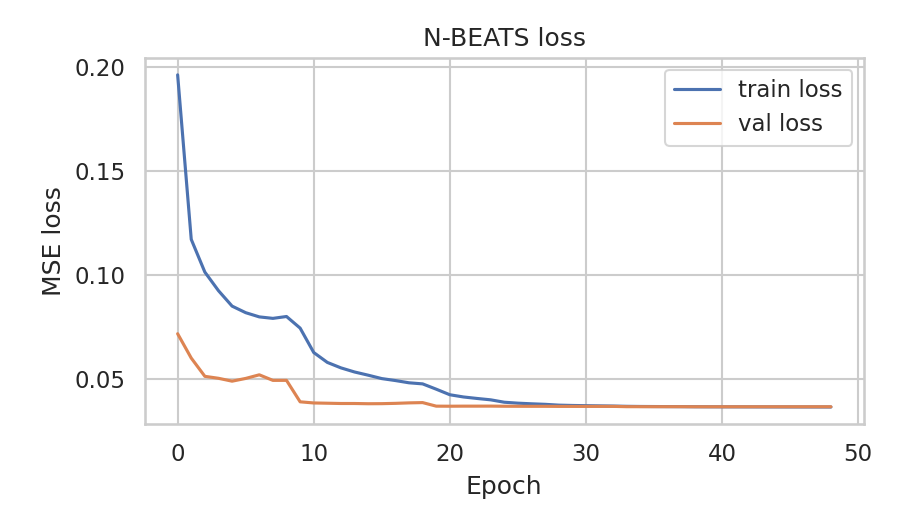

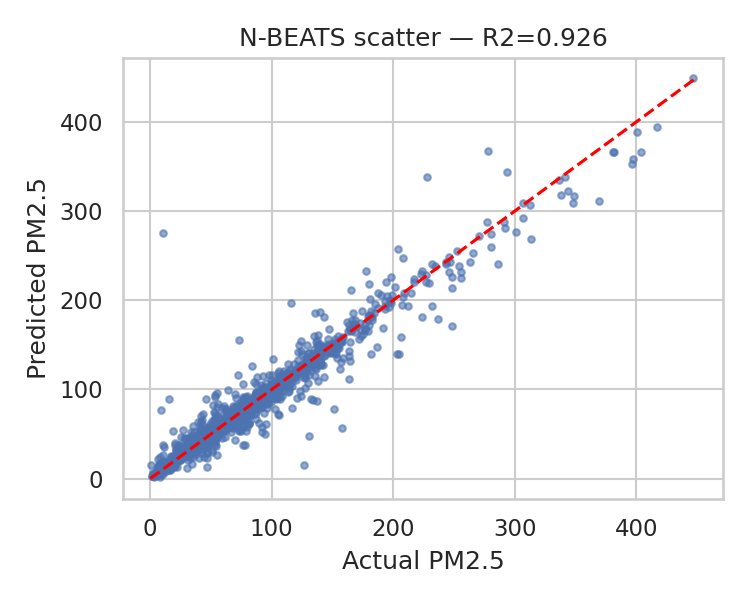

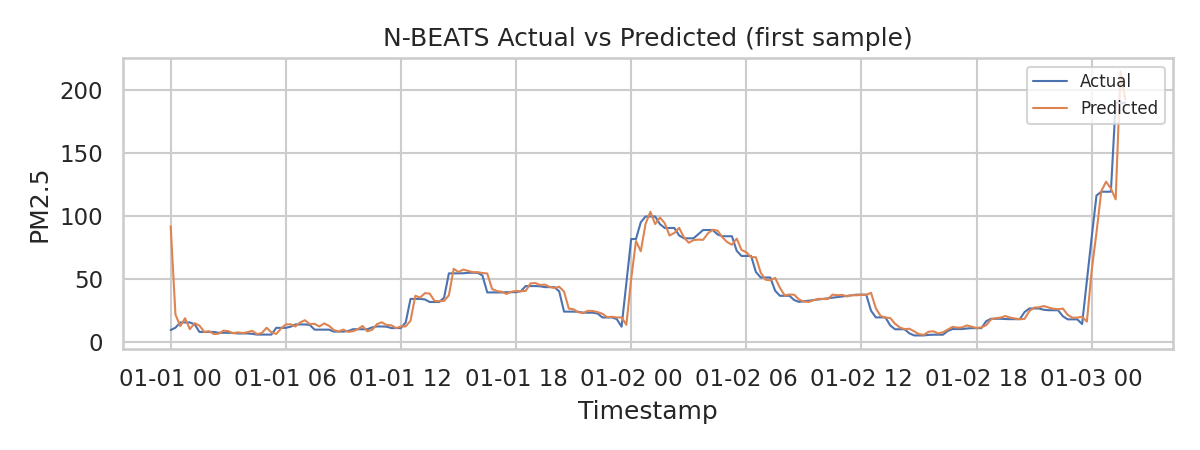

In [ ]:
from IPython.display import Image, display
display(Image("plots_nbeats/NBEATS_loss.png"))
display(Image("plots_nbeats/NBEATS_scatter.png"))
display(Image("plots_nbeats/NBEATS_timeseries.png"))


In [ ]:
# --- FAST Transformer training cell (replace slow transformer training block) ---
import os, gc, math, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
import numpy as np
import pandas as pd # Added pandas for data loading
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler # Added StandardScaler

# user-tunable / safe defaults (tweak if OOM)
CLEANED_CSV = "/content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv"   # change if your file name differs
TARGET_COL = "pm2_5"          # change if target column name differs
SEQ_LEN = 48                  # lookback length (48 x 15min = 12 hours); adjust if you want
BATCH_SIZE = 512                      # increase for GPU; lower if OOM (256,128)
EPOCHS = 40
MODEL_DIR = "models_transformer_fast"
PLOTS_DIR = "plots_transformer_fast"
PRED_DIR = "predictions_transformer_fast"
START_TEST = pd.Timestamp("2024-01-01")  # everything >= this is used as test set timestamps
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# --- Data Preparation (copied from N-BEATS cell) ---
print("Loading CSV:", CLEANED_CSV)
df = pd.read_csv(CLEANED_CSV, parse_dates=['timestamp'], low_memory=False)
df = df.sort_values('timestamp').reset_index(drop=True)
assert TARGET_COL in df.columns, f"Target column {TARGET_COL} not found"
print("Time span:", df['timestamp'].min(), "->", df['timestamp'].max())
print("Rows:", len(df))

# ---------- Build univariate sliding windows (target-only) ----------
y_full = df[[ 'timestamp', TARGET_COL ]].rename(columns={TARGET_COL: "actual"})
vals = y_full['actual'].values.astype(np.float32)

def make_sequences(vals, timestamps, seq_len):
    Xs = []
    ys = []
    times = []
    for end_idx in range(seq_len, len(vals)):
        start_idx = end_idx - seq_len
        Xs.append(vals[start_idx:end_idx].reshape(seq_len, 1))
        ys.append(vals[end_idx])
        times.append(timestamps[end_idx])
    return np.array(Xs), np.array(ys), np.array(times)

X_all, y_all, times_all = make_sequences(vals, y_full['timestamp'].values, SEQ_LEN)
print("Total sequences built:", X_all.shape, y_all.shape)

# ---------- Train/Val/Test split by time ----------
mask_test = times_all >= np.datetime64(START_TEST)
X_test, y_test, times_test = X_all[mask_test], y_all[mask_test], times_all[mask_test]
X_trainval, y_trainval, times_trainval = X_all[~mask_test], y_all[~mask_test], times_all[~mask_test]

n_tv = len(X_trainval)
val_start = int(n_tv * 0.8)
X_tr = X_trainval[:val_start]; y_tr = y_trainval[:val_start]
X_val = X_trainval[val_start:]; y_val = y_trainval[val_start:]

print("Shapes -> X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# ---------- Scaling: standardize based on train target values (univariate) ----------
scaler_x = StandardScaler()
X_tr_flat = X_tr.reshape(-1, 1)
scaler_x.fit(X_tr_flat)
def scale_X(X):
    s = X.reshape(-1,1)
    s = scaler_x.transform(s)
    return s.reshape(X.shape)
X_tr_s = scale_X(X_tr)
X_val_s = scale_X(X_val)
X_test_s = scale_X(X_test)

scaler_y = StandardScaler()
y_tr_s = scaler_y.fit_transform(y_tr.reshape(-1,1)).ravel()
y_val_s = scaler_y.transform(y_val.reshape(-1,1)).ravel()
y_test_s = scaler_y.transform(y_test.reshape(-1,1)).ravel()

# 1) Enable mixed precision (use Tensor Cores on T4)
try:
    from tensorflow.keras.mixed_precision import experimental as mixed_precision
    policy = tf.keras.mixed_precision.Policy('mixed_float16')
    tf.keras.mixed_precision.set_global_policy(policy)
    print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled:", e)

# 2) Optional: enable XLA JIT (try with/without — sometimes improves)
try:
    tf.config.optimizer.set_jit(True)
    print("XLA JIT enabled")
except Exception as e:
    print("XLA not enabled:", e)

# 3) Build efficient tf.data pipelines (cache in memory if fits, else remove .cache())
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_tr_s.astype('float32'), y_tr_s.astype('float32')))
train_ds = train_ds.cache()            # remove if memory is low
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_s.astype('float32'), y_val_s.astype('float32')))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 4) Smaller / faster Transformer architecture
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    s = np.zeros_like(angle_rads)
    s[:, 0::2] = np.sin(angle_rads[:, 0::2])
    s[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(s, dtype=tf.float32)

class FastTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=0.0)
        self.ffn = keras.Sequential([layers.Dense(dff, activation='relu'), layers.Dense(d_model)])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
    def call(self, x, training=False):
        attn = self.mha(x, x, x, training=training)
        x = self.ln1(x + attn)
        f = self.ffn(x)
        x = self.ln2(x + f)
        return x

def build_fast_transformer(seq_len, d_model=32, num_heads=2, dff=64, num_layers=2):
    inp = layers.Input(shape=(seq_len,1), dtype=tf.float32)
    x = layers.Dense(d_model, dtype=tf.float32)(inp)   # project to d_model in float32 for stability
    pe = positional_encoding(seq_len, d_model)
    x = x + pe
    for _ in range(num_layers):
        x = FastTransformerBlock(d_model=d_model, num_heads=num_heads, dff=dff)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, dtype=tf.float32)(x)        # output in float32 to avoid scaled dtype problems
    model = keras.Model(inp, out, name='fast_transformer')
    return model

# Build & compile
tf.keras.backend.clear_session()
model = build_fast_transformer(SEQ_LEN, d_model=32, num_heads=2, dff=64, num_layers=2)
opt = optimizers.Adam(learning_rate=3e-4)
model.compile(optimizer=opt, loss='mse', metrics=['mae'])
model.summary()

# 5) Callbacks: checkpoint + reduceLR + earlystop
cbs = [
    callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, "fast_transformer_best.keras"),
                              monitor='val_loss', save_best_only=True, save_weights_only=False, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-7),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

# 6) Fit — using tf.data so no steps_per_epoch needed (but you can set it)
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cbs, verbose=2)

# 7) Save final model (best already saved by checkpoint)
model.save(os.path.join(MODEL_DIR, "fast_transformer_final.keras"))

# 8) Predict on test (ensure test data is scaled and float32)
X_test_in = X_test_s.astype('float32')
y_pred = model.predict(X_test_in, batch_size=1024).ravel()
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1,1)).ravel()

# 9) Metrics & plots (loss, scatter, timeseries)
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return {"MSE":mse,"RMSE":rmse,"MAE":mae,"R2":r2}

test_metrics = metrics(y_test, y_pred)
print("Test metrics:", test_metrics)

# loss plot
plt.figure(figsize=(6,3.5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Fast Transformer loss"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend()
plt.tight_layout()
loss_path = os.path.join(PLOTS_DIR, "fast_transformer_loss.png")
plt.savefig(loss_path, dpi=150); plt.close()
print("Saved loss:", loss_path)

# scatter
import pandas as pd
out_df = pd.DataFrame({"timestamp": pd.to_datetime(times_test), "actual": y_test, "pred": y_pred})
samp = out_df.dropna()
if len(samp) > 2000: samp = samp.sample(2000, random_state=42)
plt.figure(figsize=(5,4)); plt.scatter(samp['actual'], samp['pred'], s=10, alpha=0.6)
mx = max(samp['actual'].max(), samp['pred'].max()); plt.plot([0,mx],[0,mx],'--', color='red')
plt.xlabel("Actual"); plt.ylabel("Pred"); plt.title(f"Fast Transformer scatter R2={test_metrics['R2']:.3f}")
scatter_path = os.path.join(PLOTS_DIR, "fast_transformer_scatter.png")
plt.tight_layout(); plt.savefig(scatter_path, dpi=150); plt.close()
print("Saved scatter:", scatter_path)

# timeseries overlay (first 600)
ts = out_df.sort_values('timestamp').head(200)
plt.figure(figsize=(8,3)); plt.plot(ts['timestamp'], ts['actual'], label='Actual'); plt.plot(ts['timestamp'], ts['pred'], label='Pred')
plt.legend(fontsize=8); plt.xlabel("Timestamp"); plt.ylabel("PM2.5"); plt.title("Fast Transformer timeseries")
ts_path = os.path.join(PLOTS_DIR, "fast_transformer_timeseries.png")
plt.tight_layout(); plt.savefig(ts_path, dpi=150); plt.close()
print("Saved timeseries:", ts_path)

# save preds
out_df.to_csv(os.path.join(PRED_DIR, "fast_transformer_preds.csv"), index=False)
print("Saved preds CSV.")

# 10) Cleanup
del X_all, y_all, X_tr, X_val, X_test, X_tr_s, X_val_s, X_test_s, X_trainval, y_trainval, X_tr_flat, y_tr_s, y_val_s, y_test_s, df, y_full, vals # Add df, y_full, vals for cleanup
tf.keras.backend.clear_session()
gc.collect()
print("Done. Memory cleaned.")

Loading CSV: /content/mandi_Gobindgarh_15min_cleaned_2017_2024 (1).csv
Time span: 2017-01-06 00:00:00 -> 2024-12-12 23:45:00
Rows: 105888
Total sequences built: (105840, 48, 1) (105840,)
Shapes -> X_tr: (73612, 48, 1) X_val: (18404, 48, 1) X_test: (13824, 48, 1)
Mixed precision not enabled: cannot import name 'experimental' from 'tensorflow.keras.mixed_precision' (/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/mixed_precision/__init__.py)
XLA JIT enabled


Model: "fast_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fast_transformer_block          │ (None, 48, 32)         │         8,544 │
│ (FastTransformerBlock)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fast_transformer_block_1        │ (None, 48, 32)         │         8,544 │
│ (FastTransformerBlock)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40

Epoch 1: val_loss improved from inf to 0.11086, saving model to models_transformer_fast/fast_transformer_best.keras
144/144 - 21s - 145ms/step - loss: 0.5599 - mae: 0.3604 - val_loss: 0.1109 - val_mae: 0.1900 - learning_rate: 3.0000e-04
Epoch 2/40

Epoch 2: val_loss improved from 0.11086 to 0.04568, saving model to models_transformer_fast/fast_transformer_best.keras
144/144 - 2s - 13ms/step - loss: 0.2431 - mae: 0.1558 - val_loss: 0.0457 - val_mae: 0.1016 - learning_rate: 3.0000e-04
Epoch 3/40

Epoch 3: val_loss improved from 0.04568 to 0.03847, saving model to models_transformer_fast/fast_transformer_best.keras
144/144 - 1s - 10ms/step - loss: 0.1583 - mae: 0.1227 - val_loss: 0.0385 - val_mae: 0.0909 - learning_rate: 3.0000e-04
Epoch 4/40

Epoch 4: val_loss improved from 0.03847 to 0.03814, saving model to models_transformer_fast/fast_transformer_best.keras
144/144 - 1s - 10ms/step - loss: 0.1241 - mae: 0.1139 - val_loss: 0.0381 - val_mae: 0.0872 - learning_rate: 3.0000e-0

In [ ]:
print("hello world huhu")

hello world huhu


In [ ]:
for i in range(0, 1000):
  print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27